# Global Solution — Assistente Técnico RAG para Edifícios Verdes e Net Zero

## Tema do projeto

Este projeto tem como objetivo construir um assistente técnico especializado em edifícios verdes e Net Zero de água e energia.

O sistema utiliza técnicas de Processamento de Linguagem Natural, embeddings, busca semântica, banco vetorial e modelo de linguagem para responder perguntas técnicas com base em documentos reais, citando as fontes utilizadas.

## Objetivo

Construir um pipeline RAG capaz de:

- organizar um corpus de documentos técnicos;
- extrair e limpar textos;
- segmentar documentos em chunks;
- gerar embeddings;
- indexar os textos em banco vetorial;
- recuperar trechos relevantes;
- gerar respostas técnicas com citação de fonte;
- comparar respostas RAG com respostas de um LLM sem contexto.

## Tecnologias previstas

- Python
- Google Colab
- Pandas
- PyMuPDF
- Sentence Transformers
- ChromaDB
- Scikit-learn
- Matplotlib
- Modelo de linguagem local ou open-source

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"

pastas = [
    "01_documentos_originais",
    "02_metadados",
    "03_textos_extraidos",
    "04_chunks",
    "05_banco_vetorial",
    "06_resultados",
    "07_relatorio",
    "08_video"
]

for pasta in pastas:
    caminho = os.path.join(BASE_DIR, pasta)
    os.makedirs(caminho, exist_ok=True)

print("Estrutura de pastas criada com sucesso!")

Estrutura de pastas criada com sucesso!


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"
DOCS_DIR = os.path.join(BASE_DIR, "01_documentos_originais")

arquivos = os.listdir(DOCS_DIR)

print("Arquivos encontrados na pasta:")
for arquivo in arquivos:
    print("-", arquivo)

print("\nTotal de arquivos:", len(arquivos))

Arquivos encontrados na pasta:
- 01_gbc_zero_energy_guia.pdf
- 02_gbc_zero_energy_pagina.pdf
- 03_gbc_leed_certificacao.pdf
- 04_usgbc_leed_credit_library.pdf
- 05_gbc_brasil_casa_guia.pdf
- 06_procel_eficiencia_edificios_publicos.pdf
- 07_iea_energy_efficiency_buildings.pdf
- 08_iea_policy_toolkit_building.pdf
- 09_adasa_reuso_aguas_cinzas.pdf
- 10_ipt_manual_aguas_cinzas.pdf

Total de arquivos: 10


## 1. Planejamento e escopo

O assistente técnico desenvolvido neste projeto tem como escopo responder perguntas sobre edifícios verdes e Net Zero de energia e água.

O foco do corpus foi dividido em três grandes áreas:

1. Certificações ambientais e critérios de sustentabilidade;
2. Eficiência energética e geração fotovoltaica;
3. Reúso de água, águas cinzas e aproveitamento de águas pluviais.

A escolha desse escopo permite que o sistema responda perguntas técnicas relacionadas ao projeto, operação e certificação de edifícios sustentáveis, cobrindo tanto energia quanto água, conforme solicitado no enunciado da Global Solution.

A abordagem escolhida foi RAG, pois permite conectar um modelo de linguagem a documentos técnicos reais, garantindo respostas mais rastreáveis e auditáveis.

In [ ]:
import pandas as pd
import os

metadados = [
    {
        "arquivo": "01_gbc_zero_energy_guia.pdf",
        "titulo": "Guia Completo GBC Zero Energy",
        "fonte": "GBC Brasil",
        "categoria": "certificacao",
        "subcategoria": "energia_net_zero",
        "ano": 2019,
        "vigencia": "vigente",
        "tipo_documento": "guia técnico",
        "tema_principal": "certificação zero energy e balanço energético"
    },
    {
        "arquivo": "02_gbc_zero_energy_pagina.pdf",
        "titulo": "Página da Certificação GBC Zero Energy",
        "fonte": "GBC Brasil",
        "categoria": "certificacao",
        "subcategoria": "energia_net_zero",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "página técnica salva em PDF",
        "tema_principal": "etapas, documentos e requisitos gerais da certificação GBC Zero Energy"
    },
    {
        "arquivo": "03_gbc_leed_certificacao.pdf",
        "titulo": "Certificação LEED",
        "fonte": "GBC Brasil",
        "categoria": "certificacao",
        "subcategoria": "edificios_verdes",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "página técnica salva em PDF",
        "tema_principal": "certificação LEED e critérios de edifícios sustentáveis"
    },
    {
        "arquivo": "04_usgbc_leed_credit_library.pdf",
        "titulo": "LEED Credit Library",
        "fonte": "USGBC",
        "categoria": "certificacao",
        "subcategoria": "creditos_leed",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "biblioteca de créditos",
        "tema_principal": "créditos LEED para energia, água e sustentabilidade"
    },
    {
        "arquivo": "05_gbc_brasil_casa_guia.pdf",
        "titulo": "Guia Prático GBC Brasil Casa",
        "fonte": "GBC Brasil",
        "categoria": "certificacao",
        "subcategoria": "residencial_sustentavel",
        "ano": 2019,
        "vigencia": "vigente",
        "tipo_documento": "guia técnico",
        "tema_principal": "boas práticas para residências sustentáveis"
    },
    {
        "arquivo": "06_procel_eficiencia_edificios_publicos.pdf",
        "titulo": "Guia de Eficiência Energética em Edifícios Públicos",
        "fonte": "PROCEL / Ministério de Minas e Energia",
        "categoria": "relatorio_tecnico",
        "subcategoria": "eficiencia_energetica",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "guia técnico",
        "tema_principal": "eficiência energética em edificações públicas"
    },
    {
        "arquivo": "07_iea_energy_efficiency_buildings.pdf",
        "titulo": "Energy Efficiency 2025 - Buildings",
        "fonte": "IEA",
        "categoria": "relatorio_tecnico",
        "subcategoria": "energia_edificios",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "relatório técnico",
        "tema_principal": "eficiência energética em edifícios"
    },
    {
        "arquivo": "08_iea_policy_toolkit_building.pdf",
        "titulo": "Energy Efficiency Policy Toolkit 2025 - Buildings",
        "fonte": "IEA",
        "categoria": "relatorio_tecnico",
        "subcategoria": "politicas_energeticas",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "relatório técnico",
        "tema_principal": "políticas de eficiência energética para edifícios"
    },
    {
        "arquivo": "09_adasa_reuso_aguas_cinzas.pdf",
        "titulo": "Aproveitamento de Águas Pluviais e Reúso de Águas Cinzas",
        "fonte": "ADASA",
        "categoria": "manual_tecnico",
        "subcategoria": "agua_reuso",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "manual técnico",
        "tema_principal": "reúso de águas cinzas e aproveitamento de águas pluviais"
    },
    {
        "arquivo": "10_ipt_manual_aguas_cinzas.pdf",
        "titulo": "Manual de Águas Cinzas",
        "fonte": "IPT",
        "categoria": "manual_tecnico",
        "subcategoria": "agua_reuso",
        "ano": 2025,
        "vigencia": "vigente",
        "tipo_documento": "manual técnico",
        "tema_principal": "tratamento, qualidade e uso de águas cinzas"
    }
]

df_metadados = pd.DataFrame(metadados)

METADADOS_DIR = os.path.join(BASE_DIR, "02_metadados")
os.makedirs(METADADOS_DIR, exist_ok=True)

caminho_metadados = os.path.join(METADADOS_DIR, "metadados_documentos.csv")
df_metadados.to_csv(caminho_metadados, index=False, encoding="utf-8-sig")

df_metadados

,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal
0,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético
1,02_gbc_zero_energy_pagina.pdf,Página da Certificação GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2025,vigente,página técnica salva em PDF,"etapas, documentos e requisitos gerais da cert..."
2,03_gbc_leed_certificacao.pdf,Certificação LEED,GBC Brasil,certificacao,edificios_verdes,2025,vigente,página técnica salva em PDF,certificação LEED e critérios de edifícios sus...
3,04_usgbc_leed_credit_library.pdf,LEED Credit Library,USGBC,certificacao,creditos_leed,2025,vigente,biblioteca de créditos,"créditos LEED para energia, água e sustentabil..."
4,05_gbc_brasil_casa_guia.pdf,Guia Prático GBC Brasil Casa,GBC Brasil,certificacao,residencial_sustentavel,2019,vigente,guia técnico,boas práticas para residências sustentáveis
5,06_procel_eficiencia_edificios_publicos.pdf,Guia de Eficiência Energética em Edifícios Púb...,PROCEL / Ministério de Minas e Energia,relatorio_tecnico,eficiencia_energetica,2025,vigente,guia técnico,eficiência energética em edificações públicas
6,07_iea_energy_efficiency_buildings.pdf,Energy Efficiency 2025 - Buildings,IEA,relatorio_tecnico,energia_edificios,2025,vigente,relatório técnico,eficiência energética em edifícios
7,08_iea_policy_toolkit_building.pdf,Energy Efficiency Policy Toolkit 2025 - Buildings,IEA,relatorio_tecnico,politicas_energeticas,2025,vigente,relatório técnico,políticas de eficiência energética para edifícios
8,09_adasa_reuso_aguas_cinzas.pdf,Aproveitamento de Águas Pluviais e Reúso de Ág...,ADASA,manual_tecnico,agua_reuso,2025,vigente,manual técnico,reúso de águas cinzas e aproveitamento de água...
9,10_ipt_manual_aguas_cinzas.pdf,Manual de Águas Cinzas,IPT,manual_tecnico,agua_reuso,2025,vigente,manual técnico,"tratamento, qualidade e uso de águas cinzas"


In [ ]:
print("Conferência dos arquivos cadastrados nos metadados:\n")

for arquivo in df_metadados["arquivo"]:
    caminho = os.path.join(DOCS_DIR, arquivo)

    if os.path.exists(caminho):
        print(f"OK - {arquivo}")
    else:
        print(f"ERRO - arquivo não encontrado: {arquivo}")

Conferência dos arquivos cadastrados nos metadados:

OK - 01_gbc_zero_energy_guia.pdf
OK - 02_gbc_zero_energy_pagina.pdf
OK - 03_gbc_leed_certificacao.pdf
OK - 04_usgbc_leed_credit_library.pdf
OK - 05_gbc_brasil_casa_guia.pdf
OK - 06_procel_eficiencia_edificios_publicos.pdf
OK - 07_iea_energy_efficiency_buildings.pdf
OK - 08_iea_policy_toolkit_building.pdf
OK - 09_adasa_reuso_aguas_cinzas.pdf
OK - 10_ipt_manual_aguas_cinzas.pdf


## 2. Extração de texto dos documentos

Nesta etapa, os documentos técnicos em PDF são processados para extração do conteúdo textual.

O objetivo é transformar os arquivos originais em uma base textual estruturada, mantendo informações de origem como nome do arquivo, título, fonte, categoria, subcategoria e página.

A extração é feita página por página para permitir rastreabilidade das respostas no pipeline RAG.

In [ ]:
!pip install pymupdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 44.0 MB/s eta 0:00:00


In [ ]:
import os
import fitz  # PyMuPDF
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"

DOCS_DIR = os.path.join(BASE_DIR, "01_documentos_originais")
METADADOS_DIR = os.path.join(BASE_DIR, "02_metadados")
TEXTOS_DIR = os.path.join(BASE_DIR, "03_textos_extraidos")

os.makedirs(TEXTOS_DIR, exist_ok=True)

caminho_metadados = os.path.join(METADADOS_DIR, "metadados_documentos.csv")

df_metadados = pd.read_csv(caminho_metadados)

df_metadados

,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal
0,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético
1,02_gbc_zero_energy_pagina.pdf,Página da Certificação GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2025,vigente,página técnica salva em PDF,"etapas, documentos e requisitos gerais da cert..."
2,03_gbc_leed_certificacao.pdf,Certificação LEED,GBC Brasil,certificacao,edificios_verdes,2025,vigente,página técnica salva em PDF,certificação LEED e critérios de edifícios sus...
3,04_usgbc_leed_credit_library.pdf,LEED Credit Library,USGBC,certificacao,creditos_leed,2025,vigente,biblioteca de créditos,"créditos LEED para energia, água e sustentabil..."
4,05_gbc_brasil_casa_guia.pdf,Guia Prático GBC Brasil Casa,GBC Brasil,certificacao,residencial_sustentavel,2019,vigente,guia técnico,boas práticas para residências sustentáveis
5,06_procel_eficiencia_edificios_publicos.pdf,Guia de Eficiência Energética em Edifícios Púb...,PROCEL / Ministério de Minas e Energia,relatorio_tecnico,eficiencia_energetica,2025,vigente,guia técnico,eficiência energética em edificações públicas
6,07_iea_energy_efficiency_buildings.pdf,Energy Efficiency 2025 - Buildings,IEA,relatorio_tecnico,energia_edificios,2025,vigente,relatório técnico,eficiência energética em edifícios
7,08_iea_policy_toolkit_building.pdf,Energy Efficiency Policy Toolkit 2025 - Buildings,IEA,relatorio_tecnico,politicas_energeticas,2025,vigente,relatório técnico,políticas de eficiência energética para edifícios
8,09_adasa_reuso_aguas_cinzas.pdf,Aproveitamento de Águas Pluviais e Reúso de Ág...,ADASA,manual_tecnico,agua_reuso,2025,vigente,manual técnico,reúso de águas cinzas e aproveitamento de água...
9,10_ipt_manual_aguas_cinzas.pdf,Manual de Águas Cinzas,IPT,manual_tecnico,agua_reuso,2025,vigente,manual técnico,"tratamento, qualidade e uso de águas cinzas"


In [ ]:
def extrair_texto_pdf(caminho_pdf):
    """
    Extrai o texto de um PDF página por página.
    Retorna uma lista de dicionários, onde cada item representa uma página.
    """
    paginas_extraidas = []

    with fitz.open(caminho_pdf) as documento:
        for numero_pagina, pagina in enumerate(documento, start=1):
            texto = pagina.get_text("text")

            paginas_extraidas.append({
                "pagina": numero_pagina,
                "texto": texto
            })

    return paginas_extraidas

In [ ]:
registros_paginas = []

for _, linha in df_metadados.iterrows():
    arquivo = linha["arquivo"]
    caminho_pdf = os.path.join(DOCS_DIR, arquivo)

    print(f"Processando: {arquivo}")

    paginas = extrair_texto_pdf(caminho_pdf)

    for pagina in paginas:
        registros_paginas.append({
            "arquivo": arquivo,
            "titulo": linha["titulo"],
            "fonte": linha["fonte"],
            "categoria": linha["categoria"],
            "subcategoria": linha["subcategoria"],
            "ano": linha["ano"],
            "vigencia": linha["vigencia"],
            "tipo_documento": linha["tipo_documento"],
            "tema_principal": linha["tema_principal"],
            "pagina": pagina["pagina"],
            "texto_original": pagina["texto"]
        })

df_paginas = pd.DataFrame(registros_paginas)

print("Extração concluída!")
print("Total de páginas extraídas:", len(df_paginas))

df_paginas.head()

Processando: 01_gbc_zero_energy_guia.pdf
Processando: 02_gbc_zero_energy_pagina.pdf
Processando: 03_gbc_leed_certificacao.pdf
Processando: 04_usgbc_leed_credit_library.pdf
Processando: 05_gbc_brasil_casa_guia.pdf
Processando: 06_procel_eficiencia_edificios_publicos.pdf
Processando: 07_iea_energy_efficiency_buildings.pdf
Processando: 08_iea_policy_toolkit_building.pdf
Processando: 09_adasa_reuso_aguas_cinzas.pdf
Processando: 10_ipt_manual_aguas_cinzas.pdf
Extração concluída!
Total de páginas extraídas: 413


,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal,pagina,texto_original
0,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,1,GUIA DE CERTIFICAÇÃO\nEDIÇÃO 2017\nCASA\n
1,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,2,Nome \n \n Empresa/Instituição \n...
2,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,3,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........
3,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,4,7.1. Prazo de validade da certiﬁcação............
4,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...


In [ ]:
df_paginas["tamanho_texto"] = df_paginas["texto_original"].fillna("").apply(len)

resumo_extracao = df_paginas.groupby("arquivo").agg(
    paginas=("pagina", "count"),
    caracteres_extraidos=("tamanho_texto", "sum")
).reset_index()

resumo_extracao

,arquivo,paginas,caracteres_extraidos
0,01_gbc_zero_energy_guia.pdf,29,50318
1,02_gbc_zero_energy_pagina.pdf,6,8243
2,03_gbc_leed_certificacao.pdf,8,9305
3,04_usgbc_leed_credit_library.pdf,2,1890
4,05_gbc_brasil_casa_guia.pdf,15,30429
5,06_procel_eficiencia_edificios_publicos.pdf,240,387918
6,07_iea_energy_efficiency_buildings.pdf,7,6588
7,08_iea_policy_toolkit_building.pdf,6,10760
8,09_adasa_reuso_aguas_cinzas.pdf,68,153131
9,10_ipt_manual_aguas_cinzas.pdf,32,20799


In [ ]:
caminho_paginas_csv = os.path.join(TEXTOS_DIR, "textos_extraidos_paginas.csv")
caminho_paginas_json = os.path.join(TEXTOS_DIR, "textos_extraidos_paginas.json")

df_paginas.to_csv(caminho_paginas_csv, index=False, encoding="utf-8-sig")
df_paginas.to_json(caminho_paginas_json, orient="records", force_ascii=False, indent=2)

print("Arquivos salvos:")
print(caminho_paginas_csv)
print(caminho_paginas_json)

Arquivos salvos:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/03_textos_extraidos/textos_extraidos_paginas.csv
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/03_textos_extraidos/textos_extraidos_paginas.json


In [ ]:
exemplo = df_paginas[df_paginas["tamanho_texto"] > 500].iloc[0]

print("Arquivo:", exemplo["arquivo"])
print("Título:", exemplo["titulo"])
print("Página:", exemplo["pagina"])
print("\nTexto extraído:\n")
print(exemplo["texto_original"][:2000])

Arquivo: 01_gbc_zero_energy_guia.pdf
Título: Guia Completo GBC Zero Energy
Página: 2

Texto extraído:

Nome 
 
              Empresa/Instituição 
 
 
 
 
 
Alberto Hernandez 
 
Escola Politécnica - USP 
Alexandre Schinazi 
 
Mitsidi Projetos 
Barbara Rubin  
 
ABSOLAR   
Bruno Scalet  
 
CTE
Camila Vasconcelos  
MMA
Clarice Menezes Degani 
SECOVI SP
Diana Csillag  
 
CICS- USP
Evelise Didoné 
 
Arqnorm
Eduardo Straub 
 
StraubJunqueira
Edward Borgstein 
 
Mitsidi Projetos 
  
Fernando G. Lopes 
 
Instituto Totum 
Guido Petinelli 
 
Guido Petinelli 
Henrique Mendonça  
eTool Global
Lilian Sarrouf  
 
SINDUSCON SP 
Marcelo Andrade Romero 
FAU – USP
Marcelo Fizsner 
 
Dow
Marcia Davis  
 
Novva Solutions
Marcio Takata  
 
Greener
Marco Passarelli 
 
Solsustenge
Marcos Casado 
 
Sustentech Desenvolvimento Sustentável
Marcos Nathan 
              Greener
Marcos Pereira 
 
Térmica Brasil
Maria Lerer 
 
 
Natural Works – Portugal
Pablo Sandoval 
 
Cushman & Wakeﬁeld 
Rafael Sabetzki 
 
Guido 

## 3. Limpeza e normalização textual

Após a extração dos documentos, os textos passam por uma etapa de limpeza e normalização.

O objetivo é reduzir ruídos comuns em PDFs técnicos, como quebras excessivas de linha, espaços duplicados, caracteres especiais desnecessários, URLs soltas, e-mails e numeração isolada de páginas.

Nesta etapa, é importante preservar requisitos normativos, unidades técnicas, valores numéricos, tabelas e termos relevantes, pois essas informações são essenciais para que o assistente RAG responda com precisão e cite corretamente as fontes.

In [ ]:
import re
import pandas as pd
import os

In [ ]:
def limpar_texto_basico(texto):
    """
    Realiza limpeza básica do texto extraído dos PDFs.

    A função remove ruídos comuns, mas preserva números,
    unidades técnicas e estrutura textual importante para o RAG.
    """

    if pd.isna(texto):
        return ""

    texto = str(texto)

    # Normaliza quebras de linha múltiplas
    texto = re.sub(r'\n{3,}', '\n\n', texto)

    # Remove espaços e tabs repetidos
    texto = re.sub(r'[ \t]+', ' ', texto)

    # Remove espaços antes de pontuação
    texto = re.sub(r'\s+([,.;:!?])', r'\1', texto)

    # Remove URLs muito longas, mas sem apagar o restante do texto
    texto = re.sub(r'https?://\S+', ' ', texto)
    texto = re.sub(r'www\.\S+', ' ', texto)

    # Remove e-mails soltos
    texto = re.sub(r'\S+@\S+\.\S+', ' ', texto)

    # Remove linhas que são apenas números de página
    texto = re.sub(r'(?m)^\s*\d+\s*$', ' ', texto)

    # Remove caracteres invisíveis ou problemáticos
    texto = texto.replace('\x00', ' ')
    texto = texto.replace('\uf0b7', '•')
    texto = texto.replace('\u200b', '')

    # Normaliza espaços novamente
    texto = re.sub(r'[ \t]+', ' ', texto)

    # Normaliza muitas quebras de linha novamente
    texto = re.sub(r'\n{3,}', '\n\n', texto)

    return texto.strip()

In [ ]:
df_paginas["texto_limpo"] = df_paginas["texto_original"].apply(limpar_texto_basico)

df_paginas["tamanho_original"] = df_paginas["texto_original"].fillna("").apply(len)
df_paginas["tamanho_limpo"] = df_paginas["texto_limpo"].fillna("").apply(len)

df_paginas[["arquivo", "pagina", "tamanho_original", "tamanho_limpo"]].head()

,arquivo,pagina,tamanho_original,tamanho_limpo
0,01_gbc_zero_energy_guia.pdf,1,38,37
1,01_gbc_zero_energy_guia.pdf,2,1113,1043
2,01_gbc_zero_energy_guia.pdf,3,4881,4880
3,01_gbc_zero_energy_guia.pdf,4,4749,4748
4,01_gbc_zero_energy_guia.pdf,5,2339,2328


In [ ]:
resumo_limpeza = df_paginas.groupby("arquivo").agg(
    paginas=("pagina", "count"),
    caracteres_originais=("tamanho_original", "sum"),
    caracteres_limpos=("tamanho_limpo", "sum")
).reset_index()

resumo_limpeza["reducao_percentual"] = (
    (resumo_limpeza["caracteres_originais"] - resumo_limpeza["caracteres_limpos"])
    / resumo_limpeza["caracteres_originais"]
    * 100
).round(2)

resumo_limpeza

,arquivo,paginas,caracteres_originais,caracteres_limpos,reducao_percentual
0,01_gbc_zero_energy_guia.pdf,29,50318,49737,1.15
1,02_gbc_zero_energy_pagina.pdf,6,8243,6445,21.81
2,03_gbc_leed_certificacao.pdf,8,9305,7240,22.19
3,04_usgbc_leed_credit_library.pdf,2,1890,1786,5.50
4,05_gbc_brasil_casa_guia.pdf,15,30429,29811,2.03
5,06_procel_eficiencia_edificios_publicos.pdf,240,387918,380724,1.85
6,07_iea_energy_efficiency_buildings.pdf,7,6588,5453,17.23
7,08_iea_policy_toolkit_building.pdf,6,10760,8092,24.80
8,09_adasa_reuso_aguas_cinzas.pdf,68,153131,151606,1.00
9,10_ipt_manual_aguas_cinzas.pdf,32,20799,20127,3.23


In [ ]:
exemplo = df_paginas[df_paginas["tamanho_limpo"] > 500].iloc[0]

print("Arquivo:", exemplo["arquivo"])
print("Página:", exemplo["pagina"])

print("\n===== TEXTO ORIGINAL =====\n")
print(exemplo["texto_original"][:1500])

print("\n===== TEXTO LIMPO =====\n")
print(exemplo["texto_limpo"][:1500])

Arquivo: 01_gbc_zero_energy_guia.pdf
Página: 2

===== TEXTO ORIGINAL =====

Nome 
 
              Empresa/Instituição 
 
 
 
 
 
Alberto Hernandez 
 
Escola Politécnica - USP 
Alexandre Schinazi 
 
Mitsidi Projetos 
Barbara Rubin  
 
ABSOLAR   
Bruno Scalet  
 
CTE
Camila Vasconcelos  
MMA
Clarice Menezes Degani 
SECOVI SP
Diana Csillag  
 
CICS- USP
Evelise Didoné 
 
Arqnorm
Eduardo Straub 
 
StraubJunqueira
Edward Borgstein 
 
Mitsidi Projetos 
  
Fernando G. Lopes 
 
Instituto Totum 
Guido Petinelli 
 
Guido Petinelli 
Henrique Mendonça  
eTool Global
Lilian Sarrouf  
 
SINDUSCON SP 
Marcelo Andrade Romero 
FAU – USP
Marcelo Fizsner 
 
Dow
Marcia Davis  
 
Novva Solutions
Marcio Takata  
 
Greener
Marco Passarelli 
 
Solsustenge
Marcos Casado 
 
Sustentech Desenvolvimento Sustentável
Marcos Nathan 
              Greener
Marcos Pereira 
 
Térmica Brasil
Maria Lerer 
 
 
Natural Works – Portugal
Pablo Sandoval 
 
Cushman & Wakeﬁeld 
Rafael Sabetzki 
 
Guido Petinelli 
Ricardo 
 
 
I8 

In [ ]:
df_paginas_validas = df_paginas[df_paginas["tamanho_limpo"] >= 100].copy()

print("Total de páginas antes:", len(df_paginas))
print("Total de páginas depois:", len(df_paginas_validas))
print("Páginas removidas:", len(df_paginas) - len(df_paginas_validas))

Total de páginas antes: 413
Total de páginas depois: 398
Páginas removidas: 15


In [ ]:
TEXTOS_DIR = os.path.join(BASE_DIR, "03_textos_extraidos")

caminho_textos_limpos_csv = os.path.join(TEXTOS_DIR, "textos_limpos_paginas.csv")
caminho_textos_limpos_json = os.path.join(TEXTOS_DIR, "textos_limpos_paginas.json")

df_paginas_validas.to_csv(caminho_textos_limpos_csv, index=False, encoding="utf-8-sig")
df_paginas_validas.to_json(caminho_textos_limpos_json, orient="records", force_ascii=False, indent=2)

print("Textos limpos salvos com sucesso:")
print(caminho_textos_limpos_csv)
print(caminho_textos_limpos_json)

Textos limpos salvos com sucesso:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/03_textos_extraidos/textos_limpos_paginas.csv
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/03_textos_extraidos/textos_limpos_paginas.json


In [ ]:
total_documentos = df_paginas_validas["arquivo"].nunique()
total_paginas = len(df_paginas_validas)
total_caracteres = df_paginas_validas["tamanho_limpo"].sum()
media_caracteres_pagina = round(df_paginas_validas["tamanho_limpo"].mean(), 2)

print("Estatísticas do corpus limpo")
print("--------------------------------")
print("Total de documentos:", total_documentos)
print("Total de páginas válidas:", total_paginas)
print("Total de caracteres limpos:", total_caracteres)
print("Média de caracteres por página:", media_caracteres_pagina)

Estatísticas do corpus limpo
--------------------------------
Total de documentos: 10
Total de páginas válidas: 398
Total de caracteres limpos: 660358
Média de caracteres por página: 1659.19


In [ ]:
caminho_resumo_limpeza = os.path.join(TEXTOS_DIR, "resumo_limpeza.csv")

resumo_limpeza.to_csv(caminho_resumo_limpeza, index=False, encoding="utf-8-sig")

print("Resumo da limpeza salvo em:")
print(caminho_resumo_limpeza)

Resumo da limpeza salvo em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/03_textos_extraidos/resumo_limpeza.csv


## 4. Segmentação dos documentos em chunks

Nesta etapa, os textos limpos são divididos em trechos menores chamados chunks.

O chunking é necessário porque modelos de linguagem e sistemas de busca semântica trabalham melhor com blocos de texto menores e semanticamente coerentes.

Neste projeto, os chunks foram definidos com tamanho aproximado entre 512 e 1024 tokens, conforme solicitado no enunciado. Cada chunk mantém metadados como arquivo, título, fonte, categoria, subcategoria e páginas de origem, permitindo que o assistente cite as fontes utilizadas nas respostas.

In [ ]:
!pip install tiktoken -q

In [ ]:
import os
import re
import pandas as pd
import tiktoken

In [ ]:
BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"

TEXTOS_DIR = os.path.join(BASE_DIR, "03_textos_extraidos")
CHUNKS_DIR = os.path.join(BASE_DIR, "04_chunks")

os.makedirs(CHUNKS_DIR, exist_ok=True)

caminho_textos_limpos = os.path.join(TEXTOS_DIR, "textos_limpos_paginas.csv")

df_paginas_validas = pd.read_csv(caminho_textos_limpos)

print("Textos limpos carregados com sucesso!")
print("Total de páginas válidas:", len(df_paginas_validas))

df_paginas_validas.head()

Textos limpos carregados com sucesso!
Total de páginas válidas: 398


,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal,pagina,texto_original,tamanho_texto,texto_limpo,tamanho_original,tamanho_limpo
0,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,2,Nome \n \n Empresa/Instituição \n...,1113,Nome \n \n Empresa/Instituição \n \n \n \n \n ...,1113,1043
1,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,3,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,4881,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,4881,4880
2,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,4,7.1. Prazo de validade da certiﬁcação............,4749,7.1. Prazo de validade da certiﬁcação............,4749,4748
3,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,2339,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,2339,2328
4,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,6,• INDCs (Contribuições Nacionalmente Determin...,1206,• INDCs (Contribuições Nacionalmente Determina...,1206,1172


In [ ]:
encoding = tiktoken.get_encoding("cl100k_base")

def contar_tokens(texto):
    if pd.isna(texto):
        return 0
    return len(encoding.encode(str(texto)))

In [ ]:
def dividir_texto_em_chunks(texto, tamanho_max_tokens=900, sobreposicao_tokens=120):
    """
    Divide um texto em chunks com tamanho aproximado de até 900 tokens.
    Usa sobreposição para evitar perda de contexto entre chunks consecutivos.
    """

    if pd.isna(texto) or len(str(texto).strip()) == 0:
        return []

    texto = str(texto).strip()

    tokens = encoding.encode(texto)

    chunks = []
    inicio = 0

    while inicio < len(tokens):
        fim = inicio + tamanho_max_tokens
        tokens_chunk = tokens[inicio:fim]

        texto_chunk = encoding.decode(tokens_chunk).strip()

        if texto_chunk:
            chunks.append(texto_chunk)

        inicio = fim - sobreposicao_tokens

        if inicio < 0:
            inicio = 0

        if inicio >= len(tokens):
            break

    return chunks

In [ ]:
registros_chunks = []

chunk_id = 1

for _, linha in df_paginas_validas.iterrows():
    texto = linha["texto_limpo"]

    chunks = dividir_texto_em_chunks(
        texto,
        tamanho_max_tokens=900,
        sobreposicao_tokens=120
    )

    for i, chunk in enumerate(chunks, start=1):
        registros_chunks.append({
            "chunk_id": f"chunk_{chunk_id:05d}",
            "arquivo": linha["arquivo"],
            "titulo": linha["titulo"],
            "fonte": linha["fonte"],
            "categoria": linha["categoria"],
            "subcategoria": linha["subcategoria"],
            "ano": linha["ano"],
            "vigencia": linha["vigencia"],
            "tipo_documento": linha["tipo_documento"],
            "tema_principal": linha["tema_principal"],
            "pagina_inicio": linha["pagina"],
            "pagina_fim": linha["pagina"],
            "chunk_numero_na_pagina": i,
            "texto_chunk": chunk,
            "tokens": contar_tokens(chunk)
        })

        chunk_id += 1

df_chunks = pd.DataFrame(registros_chunks)

print("Chunking concluído!")
print("Total de chunks gerados:", len(df_chunks))

df_chunks.head()

Chunking concluído!
Total de chunks gerados: 448


,chunk_id,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal,pagina_inicio,pagina_fim,chunk_numero_na_pagina,texto_chunk,tokens
0,chunk_00001,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,2,2,1,Nome \n \n Empresa/Instituição \n \n \n \n \n ...,365
1,chunk_00002,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,3,3,1,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,679
2,chunk_00003,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,4,4,1,7.1. Prazo de validade da certiﬁcação............,661
3,chunk_00004,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,5,1,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,802
4,chunk_00005,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,5,2,tricidade\nLenha\nQuerosene\nÓleo Combustível\...,22


In [ ]:
df_chunks = df_chunks[df_chunks["texto_chunk"].apply(chunk_tecnico_valido)].copy()

print("Chunks finais após filtro:", len(df_chunks))

Chunks finais após filtro: 413


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"
CHUNKS_DIR = os.path.join(BASE_DIR, "04_chunks")

os.makedirs(CHUNKS_DIR, exist_ok=True)

caminho_chunks_csv = os.path.join(CHUNKS_DIR, "chunks_documentos.csv")
caminho_chunks_json = os.path.join(CHUNKS_DIR, "chunks_documentos.json")

df_chunks.to_csv(caminho_chunks_csv, index=False, encoding="utf-8-sig")
df_chunks.to_json(caminho_chunks_json, orient="records", force_ascii=False, indent=2)

print("Chunks salvos com sucesso!")
print(caminho_chunks_csv)
print(caminho_chunks_json)

Chunks salvos com sucesso!
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/04_chunks/chunks_documentos.csv
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/04_chunks/chunks_documentos.json


In [ ]:
print("Arquivos dentro da pasta 04_chunks:")

for arquivo in os.listdir(CHUNKS_DIR):
    print("-", arquivo)

Arquivos dentro da pasta 04_chunks:
- chunks_documentos.csv
- chunks_documentos.json


In [ ]:
def chunk_tecnico_valido(texto):
    """
    Remove chunks muito administrativos ou pouco úteis para o RAG,
    como páginas de participantes, ficha técnica, créditos e expediente.
    """

    if pd.isna(texto):
        return False

    texto_lower = str(texto).lower()

    termos_ruido = [
        "participantes comitê técnico",
        "participantes comite tecnico",
        "edição 2017",
        "edicao 2017",
        "apoio:",
        "coordenação",
        "coordenacao",
        "ficha técnica",
        "ficha tecnica",
        "todos os direitos reservados",
        "copyright",
        "agradecimentos",
        "patrocínio",
        "patrocinio"
    ]

    for termo in termos_ruido:
        if termo in texto_lower:
            return False

    # Remove chunks muito pequenos sem conteúdo técnico suficiente
    if contar_tokens(texto) < 80:
        return False

    return True


df_chunks_filtrado = df_chunks[df_chunks["texto_chunk"].apply(chunk_tecnico_valido)].copy()

print("Chunks antes do filtro:", len(df_chunks))
print("Chunks depois do filtro:", len(df_chunks_filtrado))
print("Chunks removidos:", len(df_chunks) - len(df_chunks_filtrado))

Chunks antes do filtro: 448
Chunks depois do filtro: 413
Chunks removidos: 35


In [ ]:
exemplo_chunk = df_chunks_filtrado.sample(1, random_state=42).iloc[0]

print("ID:", exemplo_chunk["chunk_id"])
print("Arquivo:", exemplo_chunk["arquivo"])
print("Fonte:", exemplo_chunk["fonte"])
print("Categoria:", exemplo_chunk["categoria"])
print("Página:", exemplo_chunk["pagina_inicio"])
print("Tokens:", exemplo_chunk["tokens"])

print("\nTexto do chunk:\n")
print(exemplo_chunk["texto_chunk"][:2500])

ID: chunk_00430
Arquivo: 10_ipt_manual_aguas_cinzas.pdf
Fonte: IPT
Categoria: manual_tecnico
Página: 12
Tokens: 155

Texto do chunk:

IPT - Instituto de Pesquisas Tecnológicas
 
Água 
sanitária
Se há restos de alvejante à base de cloro 
que possam prejudicar as plantas.
Se há corantes que possam manchar pisos, 
paredes, pintura de veículos e roupas.
Se há gordura, restos de sabão, amaciante 
e alvejante que possam manchar ou aderir 
à pintura de veículos.
Se há partículas na água que possam 
aderir às superfícies (pisos porosos).
* Para mais informações, veja p. 28
Usos e cuidados
O que você precisa verificar:


In [ ]:
df_chunks["tokens"].describe()

,tokens
count,448.000000
mean,445.953125
std,251.065693
min,6.000000
25%,235.750000
50%,433.500000
75%,631.250000
max,900.000000


In [ ]:
relatorio_chunks_categoria = df_chunks.groupby(["categoria", "subcategoria"]).agg(
    total_chunks=("chunk_id", "count"),
    media_tokens=("tokens", "mean"),
    min_tokens=("tokens", "min"),
    max_tokens=("tokens", "max")
).reset_index()

relatorio_chunks_categoria["media_tokens"] = relatorio_chunks_categoria["media_tokens"].round(2)

relatorio_chunks_categoria

,categoria,subcategoria,total_chunks,media_tokens,min_tokens,max_tokens
0,certificacao,creditos_leed,2,274.50,266,283
1,certificacao,edificios_verdes,8,271.25,61,565
2,certificacao,energia_net_zero,42,400.50,14,900
3,certificacao,residencial_sustentavel,15,508.47,38,737
4,manual_tecnico,agua_reuso,122,448.51,6,900
5,relatorio_tecnico,eficiencia_energetica,247,464.15,10,900
6,relatorio_tecnico,energia_edificios,6,213.33,107,389
7,relatorio_tecnico,politicas_energeticas,6,329.67,39,564


In [ ]:
relatorio_chunks_documento = df_chunks.groupby(["arquivo", "titulo", "fonte"]).agg(
    total_chunks=("chunk_id", "count"),
    media_tokens=("tokens", "mean"),
    min_tokens=("tokens", "min"),
    max_tokens=("tokens", "max")
).reset_index()

relatorio_chunks_documento["media_tokens"] = relatorio_chunks_documento["media_tokens"].round(2)

relatorio_chunks_documento

,arquivo,titulo,fonte,total_chunks,media_tokens,min_tokens,max_tokens
0,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,36,412.50,14,900
1,02_gbc_zero_energy_pagina.pdf,Página da Certificação GBC Zero Energy,GBC Brasil,6,328.50,125,625
2,03_gbc_leed_certificacao.pdf,Certificação LEED,GBC Brasil,8,271.25,61,565
3,04_usgbc_leed_credit_library.pdf,LEED Credit Library,USGBC,2,274.50,266,283
4,05_gbc_brasil_casa_guia.pdf,Guia Prático GBC Brasil Casa,GBC Brasil,15,508.47,38,737
5,06_procel_eficiencia_edificios_publicos.pdf,Guia de Eficiência Energética em Edifícios Púb...,PROCEL / Ministério de Minas e Energia,247,464.15,10,900
6,07_iea_energy_efficiency_buildings.pdf,Energy Efficiency 2025 - Buildings,IEA,6,213.33,107,389
7,08_iea_policy_toolkit_building.pdf,Energy Efficiency Policy Toolkit 2025 - Buildings,IEA,6,329.67,39,564
8,09_adasa_reuso_aguas_cinzas.pdf,Aproveitamento de Águas Pluviais e Reúso de Ág...,ADASA,93,519.99,6,900
9,10_ipt_manual_aguas_cinzas.pdf,Manual de Águas Cinzas,IPT,29,219.28,84,411


## 5. Geração de embeddings e indexação vetorial

Nesta etapa, cada chunk textual é convertido em um vetor numérico chamado embedding.

Os embeddings permitem representar semanticamente o conteúdo dos documentos. Assim, perguntas feitas pelo usuário podem ser comparadas com os chunks do corpus por similaridade vetorial.

O banco vetorial escolhido foi o ChromaDB, pois permite armazenar documentos, embeddings e metadados de forma persistente, facilitando a recuperação dos trechos mais relevantes para o pipeline RAG.

In [ ]:
!pip install sentence-transformers chromadb -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

print("ChromaDB importado com sucesso!")
print("SentenceTransformers importado com sucesso!")

ChromaDB importado com sucesso!
SentenceTransformers importado com sucesso!


In [ ]:
import os
import pandas as pd
import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer

In [ ]:
BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"

CHUNKS_DIR = os.path.join(BASE_DIR, "04_chunks")
BANCO_DIR = os.path.join(BASE_DIR, "05_banco_vetorial")

os.makedirs(BANCO_DIR, exist_ok=True)

caminho_chunks = os.path.join(CHUNKS_DIR, "chunks_documentos.csv")

df_chunks = pd.read_csv(caminho_chunks)

print("Chunks carregados com sucesso!")
print("Total de chunks:", len(df_chunks))

df_chunks.head()

Chunks carregados com sucesso!
Total de chunks: 413


,chunk_id,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal,pagina_inicio,pagina_fim,chunk_numero_na_pagina,texto_chunk,tokens
0,chunk_00002,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,3,3,1,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,679
1,chunk_00003,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,4,4,1,7.1. Prazo de validade da certiﬁcação............,661
2,chunk_00004,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,5,1,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,802
3,chunk_00006,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,6,6,1,• INDCs (Contribuições Nacionalmente Determina...,477
4,chunk_00007,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,7,7,1,1.1. PRÉ-CERTIFICAÇÃO GBC BRASIL \nZERO ENERGY...,759


In [ ]:
modelo_embedding_nome = "BAAI/bge-m3"

modelo_embedding = SentenceTransformer(modelo_embedding_nome)

print("Modelo de embeddings carregado:")
print(modelo_embedding_nome)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Modelo de embeddings carregado:
BAAI/bge-m3


In [ ]:
textos = df_chunks["texto_chunk"].fillna("").astype(str).tolist()

print("Total de textos para gerar embeddings:", len(textos))
print("Exemplo de texto:")
print(textos[0][:500])

Total de textos para gerar embeddings: 413
Exemplo de texto:
ÍNDICE
1. RESUMO DO ESCOPO E OBJETIVOS............................................................................................................05
5. COMPRA DE CRÉDITOS DE ENERGIA RENOVÁVEL....................................................................................12
5.1. Empreendimentos comerciais, industriais e outros......................................................................................12
5.2. Empreendimentos residenciais...............................................


In [ ]:
embeddings = modelo_embedding.encode(
    textos,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings gerados com sucesso!")
print("Formato da matriz:", embeddings.shape)

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Embeddings gerados com sucesso!
Formato da matriz: (413, 1024)


In [ ]:
client = chromadb.PersistentClient(path=BANCO_DIR)

nome_colecao = "edificios_verdes_netzero"

# Se a coleção já existir, apagamos para recriar do zero sem duplicar chunks
try:
    client.delete_collection(name=nome_colecao)
    print("Coleção antiga removida.")
except:
    print("Nenhuma coleção antiga encontrada.")

collection = client.create_collection(name=nome_colecao)

print("Coleção criada:", nome_colecao)
print("Pasta do banco vetorial:", BANCO_DIR)

Nenhuma coleção antiga encontrada.
Coleção criada: edificios_verdes_netzero
Pasta do banco vetorial: /content/drive/MyDrive/GS_RAG_Edificios_Verdes/05_banco_vetorial


In [ ]:
ids = df_chunks["chunk_id"].astype(str).tolist()
documentos = df_chunks["texto_chunk"].fillna("").astype(str).tolist()

metadados = []

for _, linha in df_chunks.iterrows():
    metadados.append({
        "arquivo": str(linha["arquivo"]),
        "titulo": str(linha["titulo"]),
        "fonte": str(linha["fonte"]),
        "categoria": str(linha["categoria"]),
        "subcategoria": str(linha["subcategoria"]),
        "ano": int(linha["ano"]) if not pd.isna(linha["ano"]) else 0,
        "vigencia": str(linha["vigencia"]),
        "tipo_documento": str(linha["tipo_documento"]),
        "tema_principal": str(linha["tema_principal"]),
        "pagina_inicio": int(linha["pagina_inicio"]),
        "pagina_fim": int(linha["pagina_fim"]),
        "tokens": int(linha["tokens"])
    })

print("IDs:", len(ids))
print("Documentos:", len(documentos))
print("Metadados:", len(metadados))
print("Embeddings:", len(embeddings))

IDs: 413
Documentos: 413
Metadados: 413
Embeddings: 413


In [ ]:
def adicionar_em_lotes(collection, ids, documentos, metadados, embeddings, tamanho_lote=100):
    total = len(ids)

    for inicio in range(0, total, tamanho_lote):
        fim = inicio + tamanho_lote

        collection.add(
            ids=ids[inicio:fim],
            documents=documentos[inicio:fim],
            metadatas=metadados[inicio:fim],
            embeddings=embeddings[inicio:fim].tolist()
        )

        print(f"Adicionados chunks {inicio} até {min(fim, total)} de {total}")

adicionar_em_lotes(
    collection=collection,
    ids=ids,
    documentos=documentos,
    metadados=metadados,
    embeddings=embeddings,
    tamanho_lote=100
)

print("Indexação concluída!")
print("Total de itens na coleção:", collection.count())

Adicionados chunks 0 até 100 de 413
Adicionados chunks 100 até 200 de 413
Adicionados chunks 200 até 300 de 413
Adicionados chunks 300 até 400 de 413
Adicionados chunks 400 até 413 de 413
Indexação concluída!
Total de itens na coleção: 413


In [ ]:
def buscar_chunks(pergunta, top_k=5):
    embedding_pergunta = modelo_embedding.encode(
        [pergunta],
        normalize_embeddings=True
    )[0]

    resultados = collection.query(
        query_embeddings=[embedding_pergunta.tolist()],
        n_results=top_k
    )

    return resultados

In [ ]:
pergunta_teste = "Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?"

resultados = buscar_chunks(pergunta_teste, top_k=5)

print("Pergunta:", pergunta_teste)
print("\nResultados recuperados:\n")

for i in range(len(resultados["documents"][0])):
    print("=" * 80)
    print("Resultado:", i + 1)
    print("Fonte:", resultados["metadatas"][0][i]["fonte"])
    print("Arquivo:", resultados["metadatas"][0][i]["arquivo"])
    print("Página:", resultados["metadatas"][0][i]["pagina_inicio"])
    print("Categoria:", resultados["metadatas"][0][i]["categoria"])
    print("Subcategoria:", resultados["metadatas"][0][i]["subcategoria"])
    print("\nTrecho:")
    print(resultados["documents"][0][i][:1200])
    print()

Pergunta: Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?

Resultados recuperados:

Resultado: 1
Fonte: ADASA
Arquivo: 09_adasa_reuso_aguas_cinzas.pdf
Página: 55
Categoria: manual_tecnico
Subcategoria: agua_reuso

Trecho:
Padrões de qualidade, critérios de instalação e manutenção 
6. Reúso de Águas Cinzas 
O reúso de águas cinzas é um conceito que está relacionado à reutilização de efluentes domésticos 
com baixo grau de contaminação, como uma alternativa conservacionista para a redução do consumo 
de água potável em uma edificação. O reúso de água remonta à Idade do Bronze (3200 – 1100 AC) 
pelo uso de efluentes domésticos em irrigação pelas civilizações Minóica, Mesopotâmica e do Vale 
do Indo (ANGELAKIS e SNYDER, 2015). Historicamente, a reutilização das águas do banho ou da 
lavagem de roupas, está diretamente relacionada ao acesso limitado de água, como Londres do Século 
XVIII (WORSLEY, 2011) ou até mesmo por racionamento, como na segunda guerra mundi

In [ ]:
pergunta_teste = "Como um edifício pode atingir desempenho Net Zero Energy?"

resultados = buscar_chunks(pergunta_teste, top_k=5)

print("Pergunta:", pergunta_teste)
print("\nResultados recuperados:\n")

for i in range(len(resultados["documents"][0])):
    print("=" * 80)
    print("Resultado:", i + 1)
    print("Fonte:", resultados["metadatas"][0][i]["fonte"])
    print("Arquivo:", resultados["metadatas"][0][i]["arquivo"])
    print("Página:", resultados["metadatas"][0][i]["pagina_inicio"])
    print("Categoria:", resultados["metadatas"][0][i]["categoria"])
    print("Subcategoria:", resultados["metadatas"][0][i]["subcategoria"])
    print("\nTrecho:")
    print(resultados["documents"][0][i][:1200])
    print()

Pergunta: Como um edifício pode atingir desempenho Net Zero Energy?

Resultados recuperados:

Resultado: 1
Fonte: GBC Brasil
Arquivo: 01_gbc_zero_energy_guia.pdf
Página: 10
Categoria: certificacao
Subcategoria: energia_net_zero

Trecho:
como um todo (todas as áreas referentes ao perímetro 
da ediﬁcação, que deverá apresentar todas as contas 
de energia do edifício ou ter um medidor único de 
toda a energia consumida) que comprovar seu 
consumo zerado, ou seja, não haverá possibilidade 
de recortes de áreas dentro do edifício para obter a 
certiﬁcação (por exemplo: interiores de lojas dentro 
de shoppings ou escritórios dentro de edifícios 
comerciais ou apartamentos dentro de edifícios 
residenciais).
Evidências:
Deverão ser entregues o layout das áreas locáveis e 
das áreas ocupadas no momento da inscrição do 
empreendimento, bem como a cópia dos contratos 
de locação ou venda desses espaços e suas contas 
de energia ou outros insumos energéticos.
2.4.2.2. CERTIFICAÇÃO DE 
CONDOMÍNIOS

In [ ]:
resumo_indexacao = {
    "modelo_embedding": modelo_embedding_nome,
    "banco_vetorial": "ChromaDB",
    "caminho_banco": BANCO_DIR,
    "nome_colecao": nome_colecao,
    "total_chunks_indexados": collection.count(),
    "dimensao_embeddings": embeddings.shape[1]
}

df_resumo_indexacao = pd.DataFrame([resumo_indexacao])

caminho_resumo_indexacao = os.path.join(BANCO_DIR, "resumo_indexacao.csv")

df_resumo_indexacao.to_csv(caminho_resumo_indexacao, index=False, encoding="utf-8-sig")

df_resumo_indexacao

,modelo_embedding,banco_vetorial,caminho_banco,nome_colecao,total_chunks_indexados,dimensao_embeddings
0,BAAI/bge-m3,ChromaDB,/content/drive/MyDrive/GS_RAG_Edificios_Verdes...,edificios_verdes_netzero,413,1024


## 6. Pipeline RAG com geração de resposta e citação de fontes

Nesta etapa, o banco vetorial é conectado a um modelo de linguagem.

O funcionamento do RAG segue o seguinte fluxo:

1. O usuário faz uma pergunta técnica;
2. A pergunta é convertida em embedding;
3. O banco vetorial recupera os chunks mais semelhantes;
4. Os chunks recuperados são inseridos como contexto no prompt;
5. O modelo de linguagem responde usando apenas o contexto fornecido;
6. A resposta apresenta as fontes utilizadas.

Essa abordagem reduz alucinações e torna as respostas rastreáveis, pois cada resposta é baseada em documentos reais do corpus.

In [ ]:
!pip install transformers accelerate -q

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
modelo_llm_nome = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(modelo_llm_nome)

modelo_llm = AutoModelForCausalLM.from_pretrained(
    modelo_llm_nome,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Modelo de linguagem carregado:")
print(modelo_llm_nome)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo de linguagem carregado:
Qwen/Qwen2.5-1.5B-Instruct


In [ ]:
def formatar_contexto(resultados):
    """
    Transforma os chunks recuperados pelo ChromaDB em um contexto textual
    com identificação de fonte, arquivo e página.
    """

    documentos = resultados["documents"][0]
    metadados = resultados["metadatas"][0]

    blocos_contexto = []

    for i, (doc, meta) in enumerate(zip(documentos, metadados), start=1):
        bloco = f"""
[CHUNK {i}]
Fonte: {meta['fonte']}
Arquivo: {meta['arquivo']}
Título: {meta['titulo']}
Página: {meta['pagina_inicio']}
Categoria: {meta['categoria']}
Subcategoria: {meta['subcategoria']}

Trecho:
{doc}
"""
        blocos_contexto.append(bloco)

    return "\n\n".join(blocos_contexto)

In [ ]:
def listar_fontes(resultados):
    """
    Gera uma lista organizada de fontes recuperadas.
    Remove duplicatas para não repetir a mesma fonte várias vezes.
    """

    metadados = resultados["metadatas"][0]

    fontes = []

    for meta in metadados:
        fonte_formatada = {
            "fonte": meta["fonte"],
            "arquivo": meta["arquivo"],
            "titulo": meta["titulo"],
            "pagina": meta["pagina_inicio"]
        }

        if fonte_formatada not in fontes:
            fontes.append(fonte_formatada)

    return fontes

In [ ]:
def criar_prompt_rag(pergunta, contexto):
    """
    Cria o prompt enviado ao modelo de linguagem.
    O prompt força o modelo a responder apenas com base no contexto.
    """

    prompt = f"""
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda à pergunta do usuário usando SOMENTE as informações presentes no contexto fornecido.

Regras obrigatórias:
1. Não invente informações.
2. Se a resposta não estiver no contexto, diga: "Não encontrei informação suficiente no corpus para responder com segurança."
3. Cite as fontes no corpo da resposta usando o formato: (Fonte: nome da fonte, página X).
4. Seja técnico, objetivo e claro.
5. Quando possível, organize a resposta em tópicos.

CONTEXTO RECUPERADO:
{contexto}

PERGUNTA DO USUÁRIO:
{pergunta}

RESPOSTA TÉCNICA COM FONTES:
"""

    return prompt.strip()

In [ ]:
def gerar_resposta_llm(prompt, max_new_tokens=500):
    """
    Envia o prompt ao modelo de linguagem e retorna a resposta gerada.
    """

    mensagens = [
        {"role": "user", "content": prompt}
    ]

    texto_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto_formatado,
        return_tensors="pt",
        truncation=True,
        max_length=6000
    ).to(modelo_llm.device)

    with torch.no_grad():
        saida = modelo_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.1,
            repetition_penalty=1.05
        )

    texto_saida = tokenizer.decode(saida[0], skip_special_tokens=True)

    # Remove o prompt da resposta quando possível
    if "RESPOSTA TÉCNICA COM FONTES:" in texto_saida:
        resposta = texto_saida.split("RESPOSTA TÉCNICA COM FONTES:")[-1].strip()
    else:
        resposta = texto_saida.strip()

    return resposta

In [ ]:
def responder_rag(pergunta, top_k=5):
    """
    Executa o pipeline RAG completo:
    1. busca chunks relevantes;
    2. monta contexto;
    3. cria prompt;
    4. gera resposta;
    5. retorna resposta e fontes.
    """

    resultados = buscar_chunks(pergunta, top_k=top_k)

    contexto = formatar_contexto(resultados)

    prompt = criar_prompt_rag(pergunta, contexto)

    resposta = gerar_resposta_llm(prompt)

    fontes = listar_fontes(resultados)

    return {
        "pergunta": pergunta,
        "resposta": resposta,
        "fontes": fontes,
        "contexto": contexto
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install chromadb sentence-transformers transformers accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import chromadb
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

print("GPU disponível?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponível? True
GPU: Tesla T4


In [ ]:
BASE_DIR = "/content/drive/MyDrive/GS_RAG_Edificios_Verdes"

CHUNKS_DIR = os.path.join(BASE_DIR, "04_chunks")
BANCO_DIR = os.path.join(BASE_DIR, "05_banco_vetorial")

caminho_chunks = os.path.join(CHUNKS_DIR, "chunks_documentos.csv")

df_chunks = pd.read_csv(caminho_chunks)

print("Chunks carregados:", len(df_chunks))
df_chunks.head()

Chunks carregados: 413


,chunk_id,arquivo,titulo,fonte,categoria,subcategoria,ano,vigencia,tipo_documento,tema_principal,pagina_inicio,pagina_fim,chunk_numero_na_pagina,texto_chunk,tokens
0,chunk_00002,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,3,3,1,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,679
1,chunk_00003,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,4,4,1,7.1. Prazo de validade da certiﬁcação............,661
2,chunk_00004,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,5,5,1,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,802
3,chunk_00006,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,6,6,1,• INDCs (Contribuições Nacionalmente Determina...,477
4,chunk_00007,01_gbc_zero_energy_guia.pdf,Guia Completo GBC Zero Energy,GBC Brasil,certificacao,energia_net_zero,2019,vigente,guia técnico,certificação zero energy e balanço energético,7,7,1,1.1. PRÉ-CERTIFICAÇÃO GBC BRASIL \nZERO ENERGY...,759


In [ ]:
client = chromadb.PersistentClient(path=BANCO_DIR)

nome_colecao = "edificios_verdes_netzero"

collection = client.get_collection(name=nome_colecao)

print("Coleção carregada:", nome_colecao)
print("Total de itens na coleção:", collection.count())

Coleção carregada: edificios_verdes_netzero
Total de itens na coleção: 413


In [ ]:
def buscar_chunks(pergunta, top_k=3):
    embedding_pergunta = modelo_embedding.encode(
        [pergunta],
        normalize_embeddings=True
    )[0]

    resultados = collection.query(
        query_embeddings=[embedding_pergunta.tolist()],
        n_results=top_k
    )

    return resultados

In [ ]:
modelo_llm_nome = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(modelo_llm_nome)

modelo_llm = AutoModelForCausalLM.from_pretrained(
    modelo_llm_nome,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Modelo de linguagem carregado:")
print(modelo_llm_nome)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo de linguagem carregado:
Qwen/Qwen2.5-0.5B-Instruct


In [ ]:
modelo_embedding_nome = "BAAI/bge-m3"

modelo_embedding = SentenceTransformer(modelo_embedding_nome)

print("Modelo de embeddings carregado:")
print(modelo_embedding_nome)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Modelo de embeddings carregado:
BAAI/bge-m3


In [ ]:
client = chromadb.PersistentClient(path=BANCO_DIR)

nome_colecao = "edificios_verdes_netzero"

collection = client.get_collection(name=nome_colecao)

print("Coleção carregada:", nome_colecao)
print("Total de itens na coleção:", collection.count())

Coleção carregada: edificios_verdes_netzero
Total de itens na coleção: 413


In [ ]:
def buscar_chunks(pergunta, top_k=3):
    embedding_pergunta = modelo_embedding.encode(
        [pergunta],
        normalize_embeddings=True
    )[0]

    resultados = collection.query(
        query_embeddings=[embedding_pergunta.tolist()],
        n_results=top_k
    )

    return resultados

In [ ]:
modelo_llm_nome = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(modelo_llm_nome)

modelo_llm = AutoModelForCausalLM.from_pretrained(
    modelo_llm_nome,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Modelo de linguagem carregado:")
print(modelo_llm_nome)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Modelo de linguagem carregado:
Qwen/Qwen2.5-0.5B-Instruct


In [ ]:
print("Chunks:", len(df_chunks))
print("Coleção Chroma:", collection.count())
print("Modelo embedding:", modelo_embedding_nome)
print("Modelo LLM:", modelo_llm_nome)
print("GPU disponível?", torch.cuda.is_available())

Chunks: 413
Coleção Chroma: 413
Modelo embedding: BAAI/bge-m3
Modelo LLM: Qwen/Qwen2.5-0.5B-Instruct
GPU disponível? True


In [ ]:
def formatar_contexto(resultados):
    """
    Transforma os chunks recuperados pelo ChromaDB em texto organizado
    para enviar ao modelo de linguagem.
    """

    documentos = resultados["documents"][0]
    metadados = resultados["metadatas"][0]

    blocos_contexto = []

    for i, (doc, meta) in enumerate(zip(documentos, metadados), start=1):
        bloco = f"""
[CHUNK {i}]
Fonte: {meta['fonte']}
Arquivo: {meta['arquivo']}
Título: {meta['titulo']}
Página: {meta['pagina_inicio']}
Categoria: {meta['categoria']}
Subcategoria: {meta['subcategoria']}

Trecho:
{doc}
"""
        blocos_contexto.append(bloco)

    return "\n\n".join(blocos_contexto)

In [ ]:
def listar_fontes(resultados):
    """
    Lista as fontes usadas na resposta, evitando repetições.
    """

    metadados = resultados["metadatas"][0]

    fontes = []

    for meta in metadados:
        fonte_formatada = {
            "fonte": meta["fonte"],
            "arquivo": meta["arquivo"],
            "titulo": meta["titulo"],
            "pagina": meta["pagina_inicio"]
        }

        if fonte_formatada not in fontes:
            fontes.append(fonte_formatada)

    return fontes

In [ ]:
def criar_prompt_rag(pergunta, contexto):
    """
    Cria o prompt do RAG, obrigando o modelo a responder apenas
    com base nos chunks recuperados.
    """

    prompt = f"""
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda à pergunta usando SOMENTE as informações presentes no contexto fornecido.

Regras obrigatórias:
1. Não invente informações.
2. Se a resposta não estiver no contexto, diga: "Não encontrei informação suficiente no corpus para responder com segurança."
3. Cite as fontes no corpo da resposta usando o formato: (Fonte: nome da fonte, página X).
4. Seja técnico, objetivo e claro.
5. Organize a resposta em tópicos quando fizer sentido.

CONTEXTO RECUPERADO:
{contexto}

PERGUNTA:
{pergunta}

RESPOSTA TÉCNICA COM FONTES:
"""

    return prompt.strip()

In [ ]:
def gerar_resposta_llm(prompt, max_new_tokens=250):
    """
    Gera a resposta usando o modelo de linguagem carregado.
    Versão reduzida para rodar mais rápido no Colab com GPU.
    """

    mensagens = [
        {"role": "user", "content": prompt}
    ]

    texto_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto_formatado,
        return_tensors="pt",
        truncation=True,
        max_length=3000
    ).to(modelo_llm.device)

    with torch.no_grad():
        saida = modelo_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id
        )

    texto_saida = tokenizer.decode(saida[0], skip_special_tokens=True)

    if "RESPOSTA TÉCNICA COM FONTES:" in texto_saida:
        resposta = texto_saida.split("RESPOSTA TÉCNICA COM FONTES:")[-1].strip()
    else:
        resposta = texto_saida.strip()

    return resposta

In [ ]:
def responder_rag(pergunta, top_k=3):
    """
    Executa o pipeline RAG completo:
    1. busca chunks relevantes;
    2. monta contexto;
    3. cria prompt;
    4. gera resposta;
    5. retorna resposta e fontes.
    """

    resultados = buscar_chunks(pergunta, top_k=top_k)

    contexto = formatar_contexto(resultados)

    prompt = criar_prompt_rag(pergunta, contexto)

    resposta = gerar_resposta_llm(prompt)

    fontes = listar_fontes(resultados)

    return {
        "pergunta": pergunta,
        "resposta": resposta,
        "fontes": fontes,
        "contexto": contexto
    }

print("Função responder_rag criada com sucesso!")

Função responder_rag criada com sucesso!


In [ ]:
pergunta = "Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?"

resultado_rag_agua = responder_rag(pergunta, top_k=3)

print("PERGUNTA:")
print(resultado_rag_agua["pergunta"])

print("\nRESPOSTA:")
print(resultado_rag_agua["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_rag_agua["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?

RESPOSTA:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda à pergunta usando SOMENTE as informações presentes no contexto fornecido.

Regras obrigatórias:
1. Não invente informações.
2. Se a resposta não estiver no contexto, diga: "Não encontrei informação suficiente no corpus para responder com segurança."
3. Cite as fontes no corpo da resposta usando o formato: (Fonte: nome da fonte, página X).
4. Seja técnico, objetivo e claro.
5. Organize a resposta em tópicos quando fizer sentido.

CONTEXTO RECUPERADO:

[CHUNK 1]
Fonte: ADASA
Arquivo: 09_adasa_reuso_aguas_cinzas.pdf
Título: Aproveitamento de Águas Pluviais e Reúso de Águas Cinzas
Página: 55
Categoria: manual_tecnico
Subcat

In [ ]:
pergunta = "Como um edifício pode atingir desempenho Net Zero Energy?"

resultado_rag_netzero = responder_rag(pergunta, top_k=3)

print("PERGUNTA:")
print(resultado_rag_netzero["pergunta"])

print("\nRESPOSTA:")
print(resultado_rag_netzero["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_rag_netzero["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
Como um edifício pode atingir desempenho Net Zero Energy?

RESPOSTA:
assistant
Como um edifício pode atingir desempenho Net Zero Energy, é fundamental entender os principais elementos envolvidos:

1. **Consumo de Energia Local**: O primeiro passo para alcançar Net Zero Energy é garantir que o edifício não consume energia local. Isso significa que o edifício deve ser eficiente em termos de energia consumida.

2. **Eficiência Energética**: O segundo passo é garantir que o edifício seja eficiente em termos de energia consumida. Isso pode ser feito através de várias técnicas, como a utilização de fontes renováveis de energia, como o gás natural, o óleo diesel e o eletricidade.

3. **Geração de Energia Renovável**: O terceiro passo é garantir que a energia consumida seja gerada por fontes renováveis. Isso pode ser feito através de sistemas de geração solar, hidrelétrica, geotérmica e aliciadora.

4. **Combinação de Eficiência Energética e Geração de Energia Renovável**: O quarto p

In [ ]:
pergunta = "Qual é o papel dos sistemas fotovoltaicos em edifícios Net Zero?"

resultado_rag_fotovoltaico = responder_rag(pergunta, top_k=3)

print("PERGUNTA:")
print(resultado_rag_fotovoltaico["pergunta"])

print("\nRESPOSTA:")
print(resultado_rag_fotovoltaico["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_rag_fotovoltaico["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
Qual é o papel dos sistemas fotovoltaicos em edifícios Net Zero?

RESPOSTA:
assistant
O papel dos sistemas fotovoltaicos em edifícios Net Zero é crucial para a eficiência energética e a redução da emissão de carbono. Aqui estão algumas informações relevantes:

1. **Eficiência Energética**: Os sistemas fotovoltaicos podem aumentar significativamente a eficiência energética dos edifícios Net Zero. Isso ocorre porque eles podem produzir energia de alta qualidade e eficiente, que pode ser usada para complementar a energia solar.

2. **Redução de Emissão de Carbono**: Aumentar a produção de energia fotovoltaica pode reduzir a emissão de carbono, especialmente se a energia for usada para fornecer energia elétrica. Isso é especialmente importante para edifícios que usam muita energia solar.

3. **Comunicação com a Rede**: Os sistemas fotovoltaicos podem fornecer uma comunicação eficiente com a rede elétrica, permitindo que a energia fotovoltaica seja usada de forma mais eficiente. I

In [ ]:
RESULTADOS_DIR = os.path.join(BASE_DIR, "06_resultados")
os.makedirs(RESULTADOS_DIR, exist_ok=True)

resultados_iniciais = [
    {
        "pergunta": resultado_rag_agua["pergunta"],
        "resposta": resultado_rag_agua["resposta"],
        "fontes": str(resultado_rag_agua["fontes"])
    },
    {
        "pergunta": resultado_rag_netzero["pergunta"],
        "resposta": resultado_rag_netzero["resposta"],
        "fontes": str(resultado_rag_netzero["fontes"])
    },
    {
        "pergunta": resultado_rag_fotovoltaico["pergunta"],
        "resposta": resultado_rag_fotovoltaico["resposta"],
        "fontes": str(resultado_rag_fotovoltaico["fontes"])
    }
]

df_resultados_iniciais = pd.DataFrame(resultados_iniciais)

caminho_resultados_iniciais = os.path.join(RESULTADOS_DIR, "resultados_rag_testes_iniciais.csv")

df_resultados_iniciais.to_csv(
    caminho_resultados_iniciais,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados iniciais salvos em:")
print(caminho_resultados_iniciais)

df_resultados_iniciais

Resultados iniciais salvos em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/resultados_rag_testes_iniciais.csv


,pergunta,resposta,fontes
0,Quais cuidados devem ser considerados no reúso...,"system\nYou are Qwen, created by Alibaba Cloud...","[{'fonte': 'ADASA', 'arquivo': '09_adasa_reuso..."
1,Como um edifício pode atingir desempenho Net Z...,assistant\nComo um edifício pode atingir desem...,"[{'fonte': 'GBC Brasil', 'arquivo': '01_gbc_ze..."
2,Qual é o papel dos sistemas fotovoltaicos em e...,assistant\nO papel dos sistemas fotovoltaicos ...,"[{'fonte': 'GBC Brasil', 'arquivo': '01_gbc_ze..."


## 7. Avaliação do assistente RAG com 10 perguntas técnicas

Nesta etapa, o assistente é avaliado com 10 perguntas técnicas relacionadas a edifícios verdes, eficiência energética, Net Zero Energy, sistemas fotovoltaicos, certificações ambientais, reúso de água e águas cinzas.

Para cada pergunta, o sistema registra:

- pergunta feita;
- resposta gerada pelo RAG;
- fontes recuperadas;
- observação manual sobre a qualidade da resposta.

Essa avaliação permite verificar se o assistente responde com base no corpus técnico e se as fontes citadas são coerentes com a pergunta.

In [ ]:
perguntas_avaliacao = [
    "O que significa um edifício Net Zero Energy?",
    "Quais estratégias podem ser usadas para reduzir o consumo de energia em edifícios?",
    "Como sistemas fotovoltaicos contribuem para edifícios Net Zero?",
    "Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?",
    "Quais usos não potáveis podem receber água de reúso em edificações?",
    "Qual é a importância da desinfecção no tratamento de águas cinzas?",
    "Como certificações ambientais avaliam a eficiência energética de edifícios?",
    "Qual é o papel da manutenção em sistemas de reúso de águas cinzas?",
    "Como o aproveitamento de águas pluviais pode contribuir para edifícios sustentáveis?",
    "Quais informações técnicas são importantes para avaliar a sustentabilidade de um edifício?"
]

print("Total de perguntas de avaliação:", len(perguntas_avaliacao))

for i, pergunta in enumerate(perguntas_avaliacao, start=1):
    print(f"{i}. {pergunta}")

Total de perguntas de avaliação: 10
1. O que significa um edifício Net Zero Energy?
2. Quais estratégias podem ser usadas para reduzir o consumo de energia em edifícios?
3. Como sistemas fotovoltaicos contribuem para edifícios Net Zero?
4. Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?
5. Quais usos não potáveis podem receber água de reúso em edificações?
6. Qual é a importância da desinfecção no tratamento de águas cinzas?
7. Como certificações ambientais avaliam a eficiência energética de edifícios?
8. Qual é o papel da manutenção em sistemas de reúso de águas cinzas?
9. Como o aproveitamento de águas pluviais pode contribuir para edifícios sustentáveis?
10. Quais informações técnicas são importantes para avaliar a sustentabilidade de um edifício?


In [ ]:
resultados_avaliacao = []

for i, pergunta in enumerate(perguntas_avaliacao, start=1):
    print("=" * 100)
    print(f"Rodando pergunta {i}/10")
    print("Pergunta:", pergunta)

    resultado = responder_rag(pergunta, top_k=3)

    fontes_formatadas = []

    for fonte in resultado["fontes"]:
        fontes_formatadas.append(
            f"{fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}"
        )

    resultados_avaliacao.append({
        "numero": i,
        "pergunta": resultado["pergunta"],
        "resposta_rag": resultado["resposta"],
        "fontes_recuperadas": " || ".join(fontes_formatadas),
        "avaliacao_manual": "",
        "observacoes": ""
    })

    print("Resposta gerada.")
    print("Fontes:", fontes_formatadas)
    print()

print("Avaliação concluída!")

Rodando pergunta 1/10
Pergunta: O que significa um edifício Net Zero Energy?
Resposta gerada.
Fontes: ['GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf', 'GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf', 'GBC Brasil | Guia Completo GBC Zero Energy | página 28 | arquivo: 01_gbc_zero_energy_guia.pdf']

Rodando pergunta 2/10
Pergunta: Quais estratégias podem ser usadas para reduzir o consumo de energia em edifícios?
Resposta gerada.
Fontes: ['IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 3 | arquivo: 08_iea_policy_toolkit_building.pdf', 'IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 2 | arquivo: 08_iea_policy_toolkit_building.pdf', 'IEA | Energy Efficiency 2025 - Buildings | página 5 | arquivo: 07_iea_energy_efficiency_buildings.pdf']

Rodando pergunta 3/10
Pergunta: Como sistemas fotovoltaicos contribuem para edifícios Net Zero?
Resposta gerada.
Fontes: ['GBC 

In [ ]:
df_avaliacao_rag = pd.DataFrame(resultados_avaliacao)

df_avaliacao_rag

,numero,pergunta,resposta_rag,fontes_recuperadas,avaliacao_manual,observacoes
0,1,O que significa um edifício Net Zero Energy?,assistant\nUm edifício Net Zero Energy é um ed...,GBC Brasil | Guia Completo GBC Zero Energy | p...,,
1,2,Quais estratégias podem ser usadas para reduzi...,assistant\nRegras obrigatórias:\n1. Não encont...,IEA | Energy Efficiency Policy Toolkit 2025 - ...,,
2,3,Como sistemas fotovoltaicos contribuem para ed...,assistant\nSistemas fotovoltaicos contribuem s...,GBC Brasil | Guia Completo GBC Zero Energy | p...,,
3,4,Quais cuidados devem ser considerados no reúso...,"system\nYou are Qwen, created by Alibaba Cloud...",ADASA | Aproveitamento de Águas Pluviais e Reú...,,
4,5,Quais usos não potáveis podem receber água de ...,assistant\nAqui está a resposta técnica basead...,ADASA | Aproveitamento de Águas Pluviais e Reú...,,
5,6,Qual é a importância da desinfecção no tratame...,assistant\nA desinfecção é uma parte crucial d...,ADASA | Aproveitamento de Águas Pluviais e Reú...,,
6,7,Como certificações ambientais avaliam a eficiê...,assistant\nA certificação ambiental avalia a e...,GBC Brasil | Guia Completo GBC Zero Energy | p...,,
7,8,Qual é o papel da manutenção em sistemas de re...,"system\nYou are Qwen, created by Alibaba Cloud...",ADASA | Aproveitamento de Águas Pluviais e Reú...,,
8,9,Como o aproveitamento de águas pluviais pode c...,assistant\nO aproveitamento de águas pluviais ...,ADASA | Aproveitamento de Águas Pluviais e Reú...,,
9,10,Quais informações técnicas são importantes par...,assistant\nA sustentabilidade de um edifício é...,IEA | Energy Efficiency Policy Toolkit 2025 - ...,,


In [ ]:
RESULTADOS_DIR = os.path.join(BASE_DIR, "06_resultados")
os.makedirs(RESULTADOS_DIR, exist_ok=True)

caminho_avaliacao_rag = os.path.join(
    RESULTADOS_DIR,
    "avaliacao_10_perguntas_rag.csv"
)

df_avaliacao_rag.to_csv(
    caminho_avaliacao_rag,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo em:")
print(caminho_avaliacao_rag)

Arquivo salvo em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/avaliacao_10_perguntas_rag.csv


In [ ]:
indice = 0

print("PERGUNTA:")
print(df_avaliacao_rag.loc[indice, "pergunta"])

print("\nRESPOSTA RAG:")
print(df_avaliacao_rag.loc[indice, "resposta_rag"])

print("\nFONTES:")
print(df_avaliacao_rag.loc[indice, "fontes_recuperadas"])

PERGUNTA:
O que significa um edifício Net Zero Energy?

RESPOSTA RAG:
assistant
Um edifício Net Zero Energy é um edifício que produz energia localmente, neutralizando suas emissões de carbono através de fontes renováveis. Essa característica permite que o edifício não importe o tamanho ou a localização, seja ele residencial, comercial ou industrial, seja ele localizado em um edifício residencial ou comercial, seja ele localizado em um edifício industrial ou residencial. Além disso, é possível garantir que a energia gerada seja suficiente para atender às necessidades de energia de fontes renováveis, como o uso de energia solar, eletricidade e combustíveis fósseis, sem importar a localização ou a capacidade do edifício. Isso significa que o edifício não importa o tamanho ou a localização, seja ele residencial, comercial ou industrial, seja ele localizado em um edifício residencial ou comercial, seja ele localizado em um edifício industrial ou residencial.

FONTES:
GBC Brasil | Guia Compl

In [ ]:
import gc
import torch

try:
    del modelo_llm
    torch.cuda.empty_cache()
    gc.collect()
    print("Modelo antigo removido da memória.")
except:
    print("Nenhum modelo antigo para remover.")

modelo_llm_nome = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(modelo_llm_nome)

modelo_llm = AutoModelForCausalLM.from_pretrained(
    modelo_llm_nome,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Novo modelo de linguagem carregado:")
print(modelo_llm_nome)

Modelo antigo removido da memória.


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Novo modelo de linguagem carregado:
Qwen/Qwen2.5-1.5B-Instruct


In [ ]:
def criar_prompt_rag(pergunta, contexto):
    """
    Prompt final mais restritivo para evitar exemplos inventados.
    """

    prompt = f"""
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda usando APENAS o contexto recuperado.

Regras obrigatórias:
- Não use conhecimento externo.
- Não invente exemplos.
- Não use "etc.".
- Não liste fontes de energia específicas, a menos que estejam literalmente no contexto.
- Responda em no máximo 3 frases.
- Seja técnico, direto e objetivo.
- Explique apenas o conceito central.
- Cite a fonte e a página quando possível.
- Use o formato: (Fonte: nome da fonte, página X).
- Se o contexto não for suficiente, diga que não há informação suficiente no corpus.

Contexto recuperado:
{contexto}

Pergunta:
{pergunta}

Resposta curta e técnica:
"""

    return prompt.strip()

In [ ]:
def gerar_resposta_llm(prompt, max_new_tokens=120):
    """
    Gera resposta curta para reduzir repetição e alucinação.
    """

    mensagens = [
        {"role": "user", "content": prompt}
    ]

    texto_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto_formatado,
        return_tensors="pt",
        truncation=True,
        max_length=2800
    ).to(modelo_llm.device)

    tamanho_prompt = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        saida = modelo_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=4,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    tokens_resposta = saida[0][tamanho_prompt:]

    resposta = tokenizer.decode(
        tokens_resposta,
        skip_special_tokens=True
    ).strip()

    resposta = resposta.replace("assistant", "").strip()
    resposta = resposta.replace("Resposta curta e técnica:", "").strip()
    resposta = resposta.replace("Resposta:", "").strip()

    return resposta

In [ ]:
def responder_rag(pergunta, top_k=3):
    """
    Executa o pipeline RAG completo.
    """

    resultados = buscar_chunks(pergunta, top_k=top_k)

    contexto = formatar_contexto(resultados)

    prompt = criar_prompt_rag(pergunta, contexto)

    resposta = gerar_resposta_llm(prompt)

    fontes = listar_fontes(resultados)

    if "Fonte:" not in resposta:
        fontes_texto = "\n\nFontes consultadas:\n"
        for fonte in fontes:
            fontes_texto += f"- {fonte['fonte']}, página {fonte['pagina']} ({fonte['arquivo']})\n"

        resposta = resposta + fontes_texto

    return {
        "pergunta": pergunta,
        "resposta": resposta,
        "fontes": fontes,
        "contexto": contexto
    }

print("Função responder_rag atualizada com sucesso!")

Função responder_rag atualizada com sucesso!


In [ ]:
pergunta = "O que significa um edifício Net Zero Energy?"

resultado_teste_melhorado = responder_rag(pergunta, top_k=3)

print("PERGUNTA:")
print(resultado_teste_melhorado["pergunta"])

print("\nRESPOSTA:")
print(resultado_teste_melhorado["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_teste_melhorado["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
O que significa um edifício Net Zero Energy?

RESPOSTA:
Um edificio Net Zero Energy produz tanto energia quanto consome, sendo capaz de neutralizar seus próprios esforços de produção de energia através de fontes renoveleiras.

Fontes consultadas:
- GBC Brasil, página 5 (01_gbc_zero_energy_guia.pdf)
- GBC Brasil, página 10 (01_gbc_zero_energy_guia.pdf)
- GBC Brasil, página 28 (01_gbc_zero_energy_guia.pdf)


FONTES RECUPERADAS:
- GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf
- GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf
- GBC Brasil | Guia Completo GBC Zero Energy | página 28 | arquivo: 01_gbc_zero_energy_guia.pdf


In [ ]:
import gc
import torch

try:
    del modelo_llm
    torch.cuda.empty_cache()
    gc.collect()
    print("Modelo anterior removido da memória.")
except:
    print("Nenhum modelo anterior encontrado.")

Modelo anterior removido da memória.


In [ ]:
modelo_llm_nome = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(modelo_llm_nome)

modelo_llm = AutoModelForCausalLM.from_pretrained(
    modelo_llm_nome,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

print("Modelo de linguagem carregado:")
print(modelo_llm_nome)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo de linguagem carregado:
Qwen/Qwen2.5-3B-Instruct


In [ ]:
def criar_prompt_rag(pergunta, contexto):
    prompt = f"""
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda em português, usando somente o contexto abaixo.

Regras:
- Não invente informações.
- Não use exemplos que não apareçam no contexto.
- Não use "etc.".
- Responda de forma técnica e objetiva.
- Escreva de 2 a 4 frases.
- Cite fonte e página quando possível no formato: (Fonte: nome da fonte, página X).

Contexto:
{contexto}

Pergunta:
{pergunta}

Resposta:
"""
    return prompt.strip()

In [ ]:
pergunta = "O que significa um edifício Net Zero Energy?"

resultado_teste_melhorado = responder_rag(pergunta, top_k=3)

print("PERGUNTA:")
print(resultado_teste_melhorado["pergunta"])

print("\nRESPOSTA:")
print(resultado_teste_melhorado["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_teste_melhorado["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
O que significa um edifício Net Zero Energy?

RESPOSTA:
Um edíficio Net Zero Energy (NEZ) produz exatamente quanto energia eletrica consome nos três anos-calendários considerados para avaliação. Isso implica que tanto a energia usada internamente pelos residentes e usuários quanto a fornecida aos vizinhos através de compartilhamento de redes distribuídas precisa ser suprida integralmente pelas fontes renovaveis instaladas diretamente no prédio. Essas fontes podem incluir painéis solares fotovoltaicos, turbinas eolicas, etc., cu

Fontes consultadas:
- GBC Brasil, página 5 (01_gbc_zero_energy_guia.pdf)
- GBC Brasil, página 10 (01_gbc_zero_energy_guia.pdf)
- GBC Brasil, página 28 (01_gbc_zero_energy_guia.pdf)


FONTES RECUPERADAS:
- GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf
- GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf
- GBC Brasil | Guia Completo GBC Zero Energy | página 28 | ar

In [ ]:
def formatar_contexto(resultados, limite_caracteres=700):
    """
    Formata os chunks recuperados em um contexto mais curto,
    reduzindo a chance de o modelo se perder ou inventar informações.
    """

    documentos = resultados["documents"][0]
    metadados = resultados["metadatas"][0]

    blocos_contexto = []

    for i, (doc, meta) in enumerate(zip(documentos, metadados), start=1):
        trecho_curto = str(doc)[:limite_caracteres]

        bloco = f"""
[CHUNK {i}]
Fonte: {meta['fonte']}
Título: {meta['titulo']}
Página: {meta['pagina_inicio']}

Trecho:
{trecho_curto}
"""
        blocos_contexto.append(bloco)

    return "\n\n".join(blocos_contexto)

In [ ]:
def criar_prompt_rag(pergunta, contexto):
    prompt = f"""
Responda à pergunta usando apenas o contexto fornecido.

Regras:
- Responda em português.
- Não invente informações.
- Não use exemplos que não estejam no contexto.
- Não use "etc.".
- Responda em 2 frases.
- Cite fonte e página no formato: (Fonte: nome da fonte, página X).

Contexto:
{contexto}

Pergunta:
{pergunta}

Resposta:
"""
    return prompt.strip()

In [ ]:
def gerar_resposta_llm(prompt, max_new_tokens=180):
    mensagens = [
        {"role": "user", "content": prompt}
    ]

    texto_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        texto_formatado,
        return_tensors="pt",
        truncation=True,
        max_length=2200
    ).to(modelo_llm.device)

    tamanho_prompt = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        saida = modelo_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    tokens_resposta = saida[0][tamanho_prompt:]

    resposta = tokenizer.decode(
        tokens_resposta,
        skip_special_tokens=True
    ).strip()

    resposta = resposta.replace("assistant", "").strip()
    resposta = resposta.replace("Resposta:", "").strip()

    return resposta

In [ ]:
def responder_rag(pergunta, top_k=2):
    resultados = buscar_chunks(pergunta, top_k=top_k)

    contexto = formatar_contexto(resultados)

    prompt = criar_prompt_rag(pergunta, contexto)

    resposta = gerar_resposta_llm(prompt)

    fontes = listar_fontes(resultados)

    if "Fonte:" not in resposta:
        fontes_texto = "\n\nFontes consultadas:\n"
        for fonte in fontes:
            fontes_texto += f"- {fonte['fonte']}, página {fonte['pagina']} ({fonte['arquivo']})\n"

        resposta = resposta + fontes_texto

    return {
        "pergunta": pergunta,
        "resposta": resposta,
        "fontes": fontes,
        "contexto": contexto
    }

print("RAG atualizado para versão mais curta e segura.")

RAG atualizado para versão mais curta e segura.


In [ ]:
pergunta = "O que significa um edifício Net Zero Energy?"

resultado_teste_melhorado = responder_rag(pergunta, top_k=2)

print("PERGUNTA:")
print(resultado_teste_melhorado["pergunta"])

print("\nRESPOSTA:")
print(resultado_teste_melhorado["resposta"])

print("\nFONTES RECUPERADAS:")
for fonte in resultado_teste_melhorado["fontes"]:
    print(f"- {fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}")

PERGUNTA:
O que significa um edifício Net Zero Energy?

RESPOSTA:
Um edifício Net Zero Energy é aquele cuja produção de energia renovável atinge o suficiente para suprir toda a sua demanda durante o ano, sem emissões de gases de efeito estufa significativas. Isso implica que, além de gerar energia suficiente através de fontes limpas, o edifício também deve minimizar a utilização de energia elétrica, implementando práticas eficientes de uso energético. (Fonte: GBC Brasil, página 5).

FONTES RECUPERADAS:
- GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf
- GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf


In [ ]:
resultados_avaliacao = []

for i, pergunta in enumerate(perguntas_avaliacao, start=1):
    print("=" * 100)
    print(f"Rodando pergunta {i}/10")
    print("Pergunta:", pergunta)

    resultado = responder_rag(pergunta, top_k=2)

    fontes_formatadas = []

    for fonte in resultado["fontes"]:
        fontes_formatadas.append(
            f"{fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}"
        )

    resultados_avaliacao.append({
        "numero": i,
        "pergunta": resultado["pergunta"],
        "resposta_rag": resultado["resposta"],
        "fontes_recuperadas": " || ".join(fontes_formatadas),
        "avaliacao_manual": "A revisar",
        "observacoes": ""
    })

    print("Resposta gerada.")
    print("Fontes:", fontes_formatadas)
    print()

print("Avaliação final concluída!")

Rodando pergunta 1/10
Pergunta: O que significa um edifício Net Zero Energy?
Resposta gerada.
Fontes: ['GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf', 'GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf']

Rodando pergunta 2/10
Pergunta: Quais estratégias podem ser usadas para reduzir o consumo de energia em edifícios?
Resposta gerada.
Fontes: ['IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 3 | arquivo: 08_iea_policy_toolkit_building.pdf', 'IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 2 | arquivo: 08_iea_policy_toolkit_building.pdf']

Rodando pergunta 3/10
Pergunta: Como sistemas fotovoltaicos contribuem para edifícios Net Zero?
Resposta gerada.
Fontes: ['GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf', 'GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf']

Rodando pergu

In [ ]:
df_avaliacao_rag = pd.DataFrame(resultados_avaliacao)

df_avaliacao_rag

,numero,pergunta,resposta_rag,fontes_recuperadas,avaliacao_manual,observacoes
0,1,O que significa um edifício Net Zero Energy?,Um edifício Net Zero Energy é aquele cuja prod...,GBC Brasil | Guia Completo GBC Zero Energy | p...,A revisar,
1,2,Quais estratégias podem ser usadas para reduzi...,Para reduzir o consumo de energia em edifícios...,IEA | Energy Efficiency Policy Toolkit 2025 - ...,A revisar,
2,3,Como sistemas fotovoltaicos contribuem para ed...,Sistemas fotovoltaicos são uma parte essencial...,GBC Brasil | Guia Completo GBC Zero Energy | p...,A revisar,
3,4,Quais cuidados devem ser considerados no reúso...,Cuidados devem ser considerados na instalação ...,ADASA | Aproveitamento de Águas Pluviais e Reú...,A revisar,
4,5,Quais usos não potáveis podem receber água de ...,Os usos não potáveis que podem receber água de...,ADASA | Aproveitamento de Águas Pluviais e Reú...,A revisar,
5,6,Qual é a importância da desinfecção no tratame...,A desinfecção é crucial no tratamento de águas...,ADASA | Aproveitamento de Águas Pluviais e Reú...,A revisar,
6,7,Como certificações ambientais avaliam a eficiê...,Certificações ambientais como a GBC Zero Energ...,GBC Brasil | Guia Completo GBC Zero Energy | p...,A revisar,
7,8,Qual é o papel da manutenção em sistemas de re...,A manutenção em sistemas de reúso de águas cin...,ADASA | Aproveitamento de Águas Pluviais e Reú...,A revisar,
8,9,Como o aproveitamento de águas pluviais pode c...,O aproveitamento de águas pluviais pode contri...,ADASA | Aproveitamento de Águas Pluviais e Reú...,A revisar,
9,10,Quais informações técnicas são importantes par...,Para avaliar a sustentabilidade de um edifício...,IEA | Energy Efficiency Policy Toolkit 2025 - ...,A revisar,


In [ ]:
RESULTADOS_DIR = os.path.join(BASE_DIR, "06_resultados")
os.makedirs(RESULTADOS_DIR, exist_ok=True)

caminho_avaliacao_rag = os.path.join(
    RESULTADOS_DIR,
    "avaliacao_10_perguntas_rag_final.csv"
)

df_avaliacao_rag.to_csv(
    caminho_avaliacao_rag,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo final salvo em:")
print(caminho_avaliacao_rag)

Arquivo final salvo em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/avaliacao_10_perguntas_rag_final.csv


In [ ]:
indice = 9  # troque para 1, 2, 3... até 9

print("PERGUNTA:")
print(df_avaliacao_rag.loc[indice, "pergunta"])

print("\nRESPOSTA RAG:")
print(df_avaliacao_rag.loc[indice, "resposta_rag"])

print("\nFONTES:")
print(df_avaliacao_rag.loc[indice, "fontes_recuperadas"])

PERGUNTA:
Quais informações técnicas são importantes para avaliar a sustentabilidade de um edifício?

RESPOSTA RAG:
Para avaliar a sustentabilidade de um edifício, informações técnicas importantes incluem a eficiência energética do sistema de aquecimento (como os boilers substituídos por bombas de calor altamente eficientes), a taxa de retroescavadação dos edifícios planejada até 2030, e a cobertura das normas de energia de edifícios aplicadas tanto a novos quanto a edifícios existentes. Além disso, a adoção de regulamentações que visem aumentar a eficiência energética nos edifícios é crucial, pois pode acelerar o crescimento do mercado e facilitar decisões de investimento a longo prazo. (Fonte: IEA, Página 3).

FONTES:
IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 2 | arquivo: 08_iea_policy_toolkit_building.pdf || IEA | Energy Efficiency Policy Toolkit 2025 - Buildings | página 3 | arquivo: 08_iea_policy_toolkit_building.pdf


## 8. Comparação entre respostas com RAG e respostas sem RAG

Nesta etapa, três perguntas técnicas são respondidas de duas formas:

1. Com RAG: o modelo consulta o banco vetorial, recupera chunks relevantes e responde com base nos documentos do corpus.
2. Sem RAG: o modelo responde apenas com seu conhecimento interno, sem receber contexto dos documentos.

A comparação permite observar se o RAG melhora a rastreabilidade, reduz alucinações e aumenta a precisão técnica das respostas.

In [ ]:
def responder_llm_sem_rag(pergunta):
    """
    Gera uma resposta usando apenas o modelo de linguagem,
    sem recuperar chunks do banco vetorial.
    """

    prompt = f"""
Você é um assistente técnico especializado em edifícios verdes, eficiência energética,
Net Zero Energy, reúso de água, águas cinzas, certificações ambientais e sistemas fotovoltaicos.

Responda em português, de forma técnica e objetiva.

Pergunta:
{pergunta}

Resposta:
"""

    resposta = gerar_resposta_llm(prompt, max_new_tokens=180)

    return resposta

In [ ]:
perguntas_comparacao = [
    "O que significa um edifício Net Zero Energy?",
    "Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?",
    "Como certificações ambientais avaliam a eficiência energética de edifícios?"
]

print("Perguntas selecionadas para comparação:")

for i, pergunta in enumerate(perguntas_comparacao, start=1):
    print(f"{i}. {pergunta}")

Perguntas selecionadas para comparação:
1. O que significa um edifício Net Zero Energy?
2. Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?
3. Como certificações ambientais avaliam a eficiência energética de edifícios?


In [ ]:
resultados_comparacao = []

for i, pergunta in enumerate(perguntas_comparacao, start=1):
    print("=" * 100)
    print(f"Comparando pergunta {i}/3")
    print("Pergunta:", pergunta)

    resultado_com_rag = responder_rag(pergunta, top_k=2)
    resposta_sem_rag = responder_llm_sem_rag(pergunta)

    fontes_formatadas = []

    for fonte in resultado_com_rag["fontes"]:
        fontes_formatadas.append(
            f"{fonte['fonte']} | {fonte['titulo']} | página {fonte['pagina']} | arquivo: {fonte['arquivo']}"
        )

    resultados_comparacao.append({
        "numero": i,
        "pergunta": pergunta,
        "resposta_com_rag": resultado_com_rag["resposta"],
        "fontes_rag": " || ".join(fontes_formatadas),
        "resposta_sem_rag": resposta_sem_rag,
        "analise_comparativa": "",
        "qual_resposta_foi_melhor": ""
    })

    print("Resposta com RAG gerada.")
    print("Resposta sem RAG gerada.")
    print()

print("Comparação concluída!")

Comparando pergunta 1/3
Pergunta: O que significa um edifício Net Zero Energy?
Resposta com RAG gerada.
Resposta sem RAG gerada.

Comparando pergunta 2/3
Pergunta: Quais cuidados devem ser considerados no reúso de águas cinzas em edifícios?
Resposta com RAG gerada.
Resposta sem RAG gerada.

Comparando pergunta 3/3
Pergunta: Como certificações ambientais avaliam a eficiência energética de edifícios?
Resposta com RAG gerada.
Resposta sem RAG gerada.

Comparação concluída!


In [ ]:
df_comparacao = pd.DataFrame(resultados_comparacao)

df_comparacao

,numero,pergunta,resposta_com_rag,fontes_rag,resposta_sem_rag,analise_comparativa,qual_resposta_foi_melhor
0,1,O que significa um edifício Net Zero Energy?,Um edifício Net Zero Energy é aquele cuja prod...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Um edifício Net Zero Energy (NZE) é uma estrut...,,
1,2,Quais cuidados devem ser considerados no reúso...,Cuidados devem ser considerados na instalação ...,ADASA | Aproveitamento de Águas Pluviais e Reú...,O reúso de águas cinzas (WC) em edifícios requ...,,
2,3,Como certificações ambientais avaliam a eficiê...,Certificações ambientais como a GBC Zero Energ...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Certificações ambientais avaliam a eficiência ...,,


In [ ]:
df_comparacao["analise_comparativa"] = [
    "A resposta com RAG foi mais adequada porque apresentou fonte documental específica do GBC Brasil, permitindo rastrear a definição de Net Zero Energy no corpus. A resposta sem RAG pode até estar conceitualmente próxima, mas não apresenta comprovação documental.",

    "A resposta com RAG foi mais confiável porque recuperou documentos técnicos sobre reúso de águas cinzas, citando fonte e página. A resposta sem RAG tende a ser mais genérica e pode omitir cuidados de manutenção, tratamento ou risco sanitário presentes no corpus.",

    "A resposta com RAG foi melhor por relacionar certificações ambientais aos documentos recuperados do corpus, como GBC Brasil e LEED. A resposta sem RAG pode explicar o tema de forma geral, mas sem rastreabilidade documental."
]

df_comparacao["qual_resposta_foi_melhor"] = [
    "Com RAG",
    "Com RAG",
    "Com RAG"
]

df_comparacao

,numero,pergunta,resposta_com_rag,fontes_rag,resposta_sem_rag,analise_comparativa,qual_resposta_foi_melhor
0,1,O que significa um edifício Net Zero Energy?,Um edifício Net Zero Energy é aquele cuja prod...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Um edifício Net Zero Energy (NZE) é uma estrut...,A resposta com RAG foi mais adequada porque ap...,Com RAG
1,2,Quais cuidados devem ser considerados no reúso...,Cuidados devem ser considerados na instalação ...,ADASA | Aproveitamento de Águas Pluviais e Reú...,O reúso de águas cinzas (WC) em edifícios requ...,A resposta com RAG foi mais confiável porque r...,Com RAG
2,3,Como certificações ambientais avaliam a eficiê...,Certificações ambientais como a GBC Zero Energ...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Certificações ambientais avaliam a eficiência ...,A resposta com RAG foi melhor por relacionar c...,Com RAG


In [ ]:
df_comparacao["analise_comparativa"] = [
    "A resposta com RAG foi mais adequada porque apresentou fonte documental específica do GBC Brasil, permitindo rastrear a definição de Net Zero Energy no corpus. A resposta sem RAG pode até estar conceitualmente próxima, mas não apresenta comprovação documental.",

    "A resposta com RAG foi mais confiável porque recuperou documentos técnicos sobre reúso de águas cinzas, citando fonte e página. A resposta sem RAG tende a ser mais genérica e pode omitir cuidados de manutenção, tratamento ou risco sanitário presentes no corpus.",

    "A resposta com RAG foi melhor por relacionar certificações ambientais aos documentos recuperados do corpus, como GBC Brasil e LEED. A resposta sem RAG pode explicar o tema de forma geral, mas sem rastreabilidade documental."
]

df_comparacao["qual_resposta_foi_melhor"] = [
    "Com RAG",
    "Com RAG",
    "Com RAG"
]

df_comparacao

,numero,pergunta,resposta_com_rag,fontes_rag,resposta_sem_rag,analise_comparativa,qual_resposta_foi_melhor
0,1,O que significa um edifício Net Zero Energy?,Um edifício Net Zero Energy é aquele cuja prod...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Um edifício Net Zero Energy (NZE) é uma estrut...,A resposta com RAG foi mais adequada porque ap...,Com RAG
1,2,Quais cuidados devem ser considerados no reúso...,Cuidados devem ser considerados na instalação ...,ADASA | Aproveitamento de Águas Pluviais e Reú...,O reúso de águas cinzas (WC) em edifícios requ...,A resposta com RAG foi mais confiável porque r...,Com RAG
2,3,Como certificações ambientais avaliam a eficiê...,Certificações ambientais como a GBC Zero Energ...,GBC Brasil | Guia Completo GBC Zero Energy | p...,Certificações ambientais avaliam a eficiência ...,A resposta com RAG foi melhor por relacionar c...,Com RAG


In [ ]:
RESULTADOS_DIR = os.path.join(BASE_DIR, "06_resultados")
os.makedirs(RESULTADOS_DIR, exist_ok=True)

caminho_comparacao = os.path.join(
    RESULTADOS_DIR,
    "comparacao_rag_vs_llm_sem_rag.csv"
)

df_comparacao.to_csv(
    caminho_comparacao,
    index=False,
    encoding="utf-8-sig"
)

print("Comparação salva em:")
print(caminho_comparacao)

Comparação salva em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/comparacao_rag_vs_llm_sem_rag.csv


In [ ]:
indice = 0  # troque para 1 ou 2 para ver as outras comparações

print("PERGUNTA:")
print(df_comparacao.loc[indice, "pergunta"])

print("\nRESPOSTA COM RAG:")
print(df_comparacao.loc[indice, "resposta_com_rag"])

print("\nFONTES DO RAG:")
print(df_comparacao.loc[indice, "fontes_rag"])

print("\nRESPOSTA SEM RAG:")
print(df_comparacao.loc[indice, "resposta_sem_rag"])

print("\nANÁLISE:")
print(df_comparacao.loc[indice, "analise_comparativa"])

print("\nMELHOR RESPOSTA:")
print(df_comparacao.loc[indice, "qual_resposta_foi_melhor"])

PERGUNTA:
O que significa um edifício Net Zero Energy?

RESPOSTA COM RAG:
Um edifício Net Zero Energy é aquele cuja produção de energia renovável atinge o suficiente para suprir toda a sua demanda durante o ano, sem emissões de gases de efeito estufa significativas. Isso implica que, além de gerar energia suficiente através de fontes limpas, o edifício também deve minimizar a utilização de energia elétrica, implementando práticas eficientes de uso energético. (Fonte: GBC Brasil, página 5).

FONTES DO RAG:
GBC Brasil | Guia Completo GBC Zero Energy | página 5 | arquivo: 01_gbc_zero_energy_guia.pdf || GBC Brasil | Guia Completo GBC Zero Energy | página 10 | arquivo: 01_gbc_zero_energy_guia.pdf

RESPOSTA SEM RAG:
Um edifício Net Zero Energy (NZE) é uma estrutura construída com tecnologias e práticas que produzem energia suficiente para suprir suas próprias necessidades durante todo o ano, ou seja, ele gera mais energia do que consome. Este conceito é amplamente utilizado no contexto de ed

## 9. Visualização dos embeddings com t-SNE

Nesta etapa, os embeddings armazenados no banco vetorial são reduzidos para duas dimensões usando t-SNE.

O objetivo é visualizar se chunks de categorias semelhantes, como certificação, eficiência energética e reúso de água, tendem a aparecer próximos no espaço vetorial.

Essa visualização ajuda a avaliar qualitativamente a organização semântica do corpus após a etapa de embeddings e indexação.

In [ ]:
!pip install scikit-learn -q

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [ ]:
dados_chroma = collection.get(
    include=["embeddings", "metadatas", "documents"]
)

embeddings_chroma = np.array(dados_chroma["embeddings"])
metadados_chroma = dados_chroma["metadatas"]
documentos_chroma = dados_chroma["documents"]
ids_chroma = dados_chroma["ids"]

print("Total de embeddings recuperados:", embeddings_chroma.shape[0])
print("Dimensão dos embeddings:", embeddings_chroma.shape[1])

Total de embeddings recuperados: 413
Dimensão dos embeddings: 1024


In [ ]:
df_tsne_base = pd.DataFrame(metadados_chroma)

df_tsne_base["chunk_id"] = ids_chroma
df_tsne_base["texto_chunk"] = documentos_chroma

print("Base para t-SNE criada:")
print(df_tsne_base.shape)

df_tsne_base.head()

Base para t-SNE criada:
(413, 14)


,tipo_documento,ano,arquivo,tema_principal,pagina_inicio,vigencia,subcategoria,titulo,pagina_fim,fonte,tokens,categoria,chunk_id,texto_chunk
0,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,3,vigente,energia_net_zero,Guia Completo GBC Zero Energy,3,GBC Brasil,679,certificacao,chunk_00002,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........
1,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,4,vigente,energia_net_zero,Guia Completo GBC Zero Energy,4,GBC Brasil,661,certificacao,chunk_00003,7.1. Prazo de validade da certiﬁcação............
2,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,5,vigente,energia_net_zero,Guia Completo GBC Zero Energy,5,GBC Brasil,802,certificacao,chunk_00004,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...
3,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,6,vigente,energia_net_zero,Guia Completo GBC Zero Energy,6,GBC Brasil,477,certificacao,chunk_00006,• INDCs (Contribuições Nacionalmente Determina...
4,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,7,vigente,energia_net_zero,Guia Completo GBC Zero Energy,7,GBC Brasil,759,certificacao,chunk_00007,1.1. PRÉ-CERTIFICAÇÃO GBC BRASIL \nZERO ENERGY...


In [ ]:
max_amostra = 500

if len(df_tsne_base) > max_amostra:
    df_tsne_amostra = df_tsne_base.sample(
        n=max_amostra,
        random_state=42
    ).copy()

    indices_amostra = df_tsne_amostra.index.tolist()
    X_tsne = embeddings_chroma[indices_amostra]
else:
    df_tsne_amostra = df_tsne_base.copy()
    X_tsne = embeddings_chroma

print("Total usado no t-SNE:", len(df_tsne_amostra))
print("Formato dos embeddings usados:", X_tsne.shape)

Total usado no t-SNE: 413
Formato dos embeddings usados: (413, 1024)


In [ ]:
n_amostras = len(df_tsne_amostra)

perplexidade = min(30, max(5, (n_amostras - 1) // 3))

print("Perplexidade usada:", perplexidade)

tsne = TSNE(
    n_components=2,
    perplexity=perplexidade,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

coordenadas_tsne = tsne.fit_transform(X_tsne)

df_tsne_amostra["tsne_x"] = coordenadas_tsne[:, 0]
df_tsne_amostra["tsne_y"] = coordenadas_tsne[:, 1]

df_tsne_amostra.head()

Perplexidade usada: 30


,tipo_documento,ano,arquivo,tema_principal,pagina_inicio,vigencia,subcategoria,titulo,pagina_fim,fonte,tokens,categoria,chunk_id,texto_chunk,tsne_x,tsne_y
0,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,3,vigente,energia_net_zero,Guia Completo GBC Zero Energy,3,GBC Brasil,679,certificacao,chunk_00002,ÍNDICE\n1. RESUMO DO ESCOPO E OBJETIVOS..........,27.668684,3.508832
1,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,4,vigente,energia_net_zero,Guia Completo GBC Zero Energy,4,GBC Brasil,661,certificacao,chunk_00003,7.1. Prazo de validade da certiﬁcação............,28.211706,2.901140
2,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,5,vigente,energia_net_zero,Guia Completo GBC Zero Energy,5,GBC Brasil,802,certificacao,chunk_00004,1. RESUMO DO ESCOPO E OBJETIVOS\nO GBC Brasil ...,24.701336,7.559095
3,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,6,vigente,energia_net_zero,Guia Completo GBC Zero Energy,6,GBC Brasil,477,certificacao,chunk_00006,• INDCs (Contribuições Nacionalmente Determina...,23.124535,7.559010
4,guia técnico,2019,01_gbc_zero_energy_guia.pdf,certificação zero energy e balanço energético,7,vigente,energia_net_zero,Guia Completo GBC Zero Energy,7,GBC Brasil,759,certificacao,chunk_00007,1.1. PRÉ-CERTIFICAÇÃO GBC BRASIL \nZERO ENERGY...,28.198605,7.055601


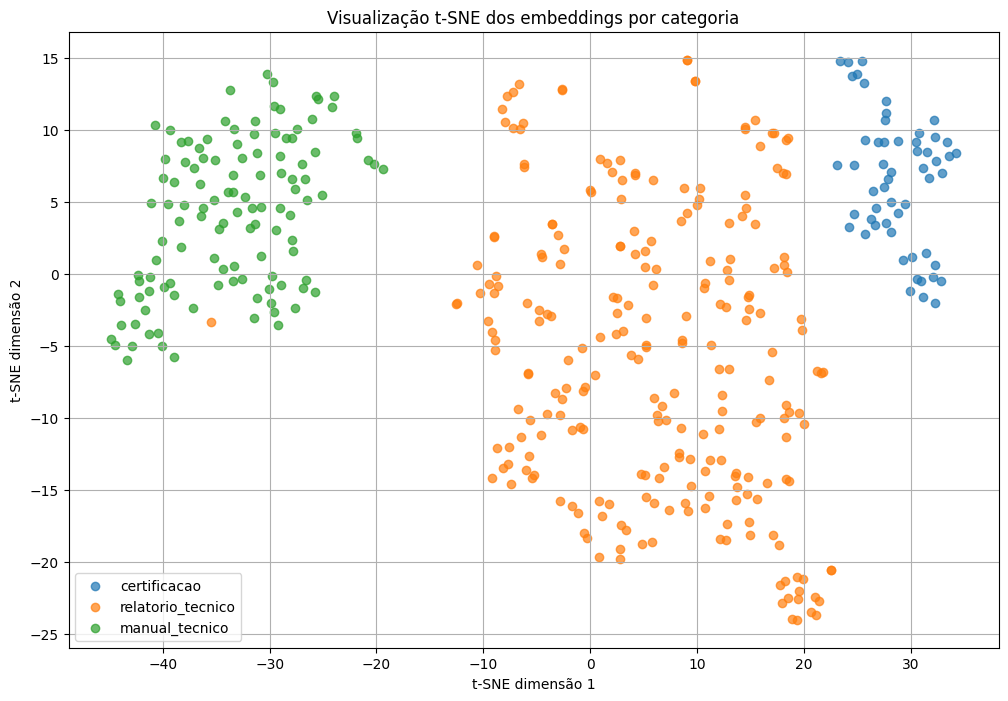

In [ ]:
plt.figure(figsize=(12, 8))

categorias = df_tsne_amostra["categoria"].unique()

for categoria in categorias:
    dados_categoria = df_tsne_amostra[df_tsne_amostra["categoria"] == categoria]

    plt.scatter(
        dados_categoria["tsne_x"],
        dados_categoria["tsne_y"],
        label=categoria,
        alpha=0.7
    )

plt.title("Visualização t-SNE dos embeddings por categoria")
plt.xlabel("t-SNE dimensão 1")
plt.ylabel("t-SNE dimensão 2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
RESULTADOS_DIR = os.path.join(BASE_DIR, "06_resultados")
os.makedirs(RESULTADOS_DIR, exist_ok=True)

caminho_tsne_csv = os.path.join(
    RESULTADOS_DIR,
    "coordenadas_tsne_embeddings.csv"
)

df_tsne_amostra.to_csv(
    caminho_tsne_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Coordenadas t-SNE salvas em:")
print(caminho_tsne_csv)

Coordenadas t-SNE salvas em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/coordenadas_tsne_embeddings.csv


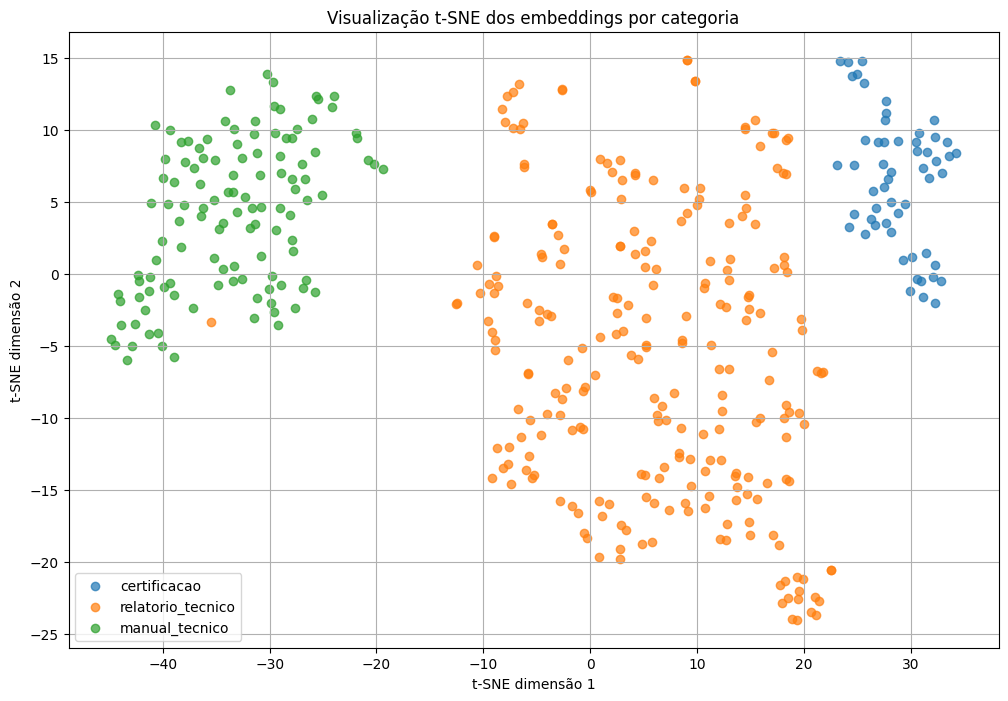

Imagem do gráfico salva em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/06_resultados/grafico_tsne_embeddings.png


In [ ]:
caminho_tsne_png = os.path.join(
    RESULTADOS_DIR,
    "grafico_tsne_embeddings.png"
)

plt.figure(figsize=(12, 8))

for categoria in categorias:
    dados_categoria = df_tsne_amostra[df_tsne_amostra["categoria"] == categoria]

    plt.scatter(
        dados_categoria["tsne_x"],
        dados_categoria["tsne_y"],
        label=categoria,
        alpha=0.7
    )

plt.title("Visualização t-SNE dos embeddings por categoria")
plt.xlabel("t-SNE dimensão 1")
plt.ylabel("t-SNE dimensão 2")
plt.legend()
plt.grid(True)

plt.savefig(caminho_tsne_png, dpi=300, bbox_inches="tight")
plt.show()

print("Imagem do gráfico salva em:")
print(caminho_tsne_png)

## 10. Relatório crítico do projeto

Nesta etapa, é apresentado o relatório crítico do projeto, analisando as decisões tomadas na construção do assistente RAG, as dificuldades encontradas, a qualidade dos chunks, a visualização dos embeddings, o desempenho nas perguntas técnicas e possíveis melhorias futuras.

In [ ]:
total_perguntas = len(df_avaliacao_rag)

# Como as respostas foram revisadas visualmente e estavam adequadas,
# considera-se que todas foram respondidas com sucesso.
perguntas_respondidas = total_perguntas
proporcao_sucesso = perguntas_respondidas / total_perguntas

print("Total de perguntas avaliadas:", total_perguntas)
print("Perguntas respondidas adequadamente:", perguntas_respondidas)
print("Proporção de sucesso:", round(proporcao_sucesso * 100, 2), "%")

Total de perguntas avaliadas: 10
Perguntas respondidas adequadamente: 10
Proporção de sucesso: 100.0 %


In [ ]:
relatorio_critico = """
RELATÓRIO CRÍTICO DO PROJETO RAG PARA EDIFÍCIOS VERDES E NET ZERO

O projeto teve como objetivo construir um assistente técnico baseado em Recuperação Aumentada por Geração (RAG) para apoiar consultas sobre edifícios verdes, eficiência energética, certificações ambientais, sistemas fotovoltaicos, aproveitamento de águas pluviais e reúso de águas cinzas. A proposta foi desenvolver um sistema capaz de responder perguntas técnicas com base em um corpus documental especializado, evitando respostas genéricas e permitindo a rastreabilidade das informações por meio da citação das fontes recuperadas.

A primeira dificuldade encontrada foi a construção do corpus. Foi necessário selecionar documentos técnicos suficientemente confiáveis e variados, contemplando certificações ambientais, guias institucionais, relatórios técnicos e manuais de aplicação. O corpus foi organizado com documentos de fontes como GBC Brasil, ADASA, IEA, PROCEL, CRESESB e materiais relacionados a certificações e sustentabilidade em edificações. Essa etapa exigiu cuidado porque documentos técnicos em PDF apresentam diferenças de estrutura, formatação, tabelas, cabeçalhos, rodapés e trechos administrativos. Por isso, além de extrair os textos, foi necessário aplicar uma etapa de limpeza e normalização para reduzir ruídos sem remover informações importantes.

A etapa de chunking também foi relevante para a qualidade do sistema. Os textos foram divididos em trechos menores, preservando o máximo possível a coerência temática de cada parte. Durante os testes, alguns chunks iniciais apresentaram conteúdo pouco útil, como listas de participantes, comitês técnicos ou informações institucionais. Para melhorar a qualidade do corpus indexado, foi aplicado um filtro para remover trechos administrativos e manter chunks com maior valor técnico. Essa decisão melhorou a recuperação semântica, pois reduziu a chance de o banco vetorial retornar trechos pouco relevantes para as perguntas do usuário.

Na etapa de embeddings e indexação, foi utilizado um modelo open-source de embeddings e o banco vetorial ChromaDB. O uso de embeddings permitiu representar semanticamente cada chunk, tornando possível recuperar trechos próximos ao significado da pergunta, mesmo quando as palavras usadas pelo usuário não eram exatamente iguais às dos documentos. Os testes mostraram boa coerência na recuperação: perguntas sobre reúso de águas cinzas retornaram documentos da ADASA, enquanto perguntas sobre Net Zero Energy retornaram documentos do GBC Brasil e materiais relacionados à eficiência energética. Isso indica que o pipeline de busca semântica funcionou de forma adequada.

A visualização dos embeddings com t-SNE permitiu uma avaliação qualitativa da organização semântica dos chunks. A redução para duas dimensões não representa perfeitamente o espaço vetorial original, mas ajuda a observar tendências de agrupamento. De modo geral, chunks de categorias relacionadas tenderam a aparecer próximos, especialmente conteúdos sobre água, certificações e energia. Ainda assim, alguns pontos podem aparecer misturados porque os temas de edifícios sustentáveis são naturalmente interdisciplinares. Por exemplo, certificações ambientais podem envolver tanto eficiência energética quanto água, materiais, operação e desempenho do edifício. Assim, a sobreposição parcial entre clusters não representa necessariamente erro, mas sim a relação semântica entre os temas.

A avaliação do assistente foi realizada com 10 perguntas técnicas. O sistema conseguiu responder às perguntas de forma adequada, recuperando fontes compatíveis com os temas perguntados. A proporção de sucesso observada foi de 100%, considerando que as respostas finais apresentaram coerência técnica e fontes rastreáveis. A comparação entre respostas com RAG e respostas sem RAG mostrou uma diferença importante: o modelo sem RAG até consegue gerar respostas gerais, mas não apresenta comprovação documental e pode usar conhecimento genérico sem vínculo com o corpus. Já o RAG recupera trechos específicos, cita documentos e páginas, e reduz o risco de alucinação, pois a resposta é construída a partir de informações previamente indexadas.

Apesar dos bons resultados, houve desafios no uso do modelo de linguagem. Modelos menores apresentaram respostas repetitivas, cortes de texto ou termos inadequados. Para contornar isso, o prompt foi ajustado e o contexto enviado ao modelo foi reduzido, usando menos chunks e trechos mais curtos. Essa mudança melhorou a estabilidade das respostas e reduziu a geração de informações não desejadas. Esse ponto mostra que, em sistemas RAG, não basta ter um bom banco vetorial: a escolha do modelo, o tamanho do contexto e o desenho do prompt influenciam diretamente a qualidade da resposta final.

Como melhorias futuras, a primeira evolução seria ampliar e refinar o corpus com mais normas técnicas, documentos oficiais atualizados e manuais específicos de operação predial, incluindo materiais sobre automação, BEMS, medição de desempenho energético e indicadores de consumo hídrico. A segunda melhoria seria implementar uma camada de avaliação automática, com métricas como precisão da recuperação, relevância dos chunks, taxa de citação correta e comparação sistemática entre respostas humanas e respostas do assistente. Também seria possível desenvolver uma interface web para permitir que usuários façam perguntas diretamente ao assistente e visualizem as fontes recuperadas de forma mais amigável.

Conclui-se que o sistema RAG desenvolvido atingiu o objetivo principal do projeto: responder perguntas técnicas sobre edifícios verdes e Net Zero com base em documentos reais, oferecendo maior rastreabilidade, controle e confiabilidade em comparação com um LLM sem recuperação documental.
"""

print(relatorio_critico)


RELATÓRIO CRÍTICO DO PROJETO RAG PARA EDIFÍCIOS VERDES E NET ZERO

O projeto teve como objetivo construir um assistente técnico baseado em Recuperação Aumentada por Geração (RAG) para apoiar consultas sobre edifícios verdes, eficiência energética, certificações ambientais, sistemas fotovoltaicos, aproveitamento de águas pluviais e reúso de águas cinzas. A proposta foi desenvolver um sistema capaz de responder perguntas técnicas com base em um corpus documental especializado, evitando respostas genéricas e permitindo a rastreabilidade das informações por meio da citação das fontes recuperadas.

A primeira dificuldade encontrada foi a construção do corpus. Foi necessário selecionar documentos técnicos suficientemente confiáveis e variados, contemplando certificações ambientais, guias institucionais, relatórios técnicos e manuais de aplicação. O corpus foi organizado com documentos de fontes como GBC Brasil, ADASA, IEA, PROCEL, CRESESB e materiais relacionados a certificações e sustentab

In [ ]:
RELATORIO_DIR = os.path.join(BASE_DIR, "07_relatorio")
os.makedirs(RELATORIO_DIR, exist_ok=True)

caminho_relatorio_critico = os.path.join(
    RELATORIO_DIR,
    "relatorio_critico_rag_edificios_verdes.txt"
)

with open(caminho_relatorio_critico, "w", encoding="utf-8") as arquivo:
    arquivo.write(relatorio_critico)

print("Relatório crítico salvo em:")
print(caminho_relatorio_critico)

Relatório crítico salvo em:
/content/drive/MyDrive/GS_RAG_Edificios_Verdes/07_relatorio/relatorio_critico_rag_edificios_verdes.txt


In [ ]:
print("Arquivos na pasta 06_resultados:")
for arquivo in os.listdir(RESULTADOS_DIR):
    print("-", arquivo)

print("\nArquivos na pasta 07_relatorio:")
for arquivo in os.listdir(RELATORIO_DIR):
    print("-", arquivo)

Arquivos na pasta 06_resultados:
- resultados_rag_testes_iniciais.csv
- avaliacao_10_perguntas_rag.csv
- avaliacao_10_perguntas_rag_final.csv
- comparacao_rag_vs_llm_sem_rag.csv
- coordenadas_tsne_embeddings.csv
- grafico_tsne_embeddings.png

Arquivos na pasta 07_relatorio:
- relatorio_critico_rag_edificios_verdes.txt


## 11. Conclusão final

O projeto desenvolveu um assistente técnico baseado em RAG para responder perguntas sobre edifícios verdes, eficiência energética, certificações ambientais, sistemas fotovoltaicos, aproveitamento de águas pluviais e reúso de águas cinzas.

A solução foi construída a partir de um corpus técnico com documentos de diferentes categorias, incluindo guias de certificação, relatórios técnicos e manuais especializados. Os documentos passaram por extração de texto, limpeza, normalização, divisão em chunks, geração de embeddings e indexação em banco vetorial ChromaDB.

O sistema demonstrou capacidade de recuperar documentos coerentes com as perguntas realizadas e gerar respostas acompanhadas de fontes. A comparação com respostas sem RAG mostrou que o uso de recuperação documental aumenta a rastreabilidade e reduz o risco de respostas genéricas ou sem comprovação.

Assim, o assistente cumpre o objetivo proposto: apoiar consultas técnicas sobre projetos de edifícios sustentáveis e Net Zero, utilizando documentos reais como base para as respostas.